# 🚨 Anomaly Detection — Finding the Needles When You Barely Know What a Needle Looks Like

> **What you'll learn:** the difference between outliers, novelties and anomalies; robust statistical baselines (z-score, median/MAD, IQR, Mahalanobis with MinCovDet) and how they fail; how Isolation Forest, Local Outlier Factor, One-Class SVM, Gaussian-mixture densities and PCA reconstruction error score "strangeness"; PyOD's unified toolbox; and, most importantly, how to **evaluate and threshold** detectors when labels are scarce (PR-AUC, precision@k, review budgets). You will build Isolation Forest from scratch and run a fraud review queue on real credit-card data.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Dimensionality Reduction](14_Dimensionality_Reduction_PCA_tSNE_UMAP.ipynb) (PCA reconstruction) · [Clustering: DBSCAN and Gaussian Mixtures](13_Clustering_DBSCAN_and_Gaussian_Mixtures.ipynb) (densities, GMM log-likelihood) · [Random Forest and Bagging](09_Random_Forest_and_Bagging.ipynb) (trees, ensembles of random trees) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · pyod 3.6 · scipy 1.18 · numpy 2.5 · pandas 3.0 · seaborn 0.13 |
| **Interview relevance** | ⭐⭐⭐ High — "how does Isolation Forest work?", "LOF vs Isolation Forest", "why is accuracy useless for fraud?", "ROC-AUC or PR-AUC?", "what does `contamination` do?", "you have no labels — how do you evaluate?", "design a fraud review queue" |

## 🤔 What Is Anomaly Detection?

Your bank texts you: *"Did you just spend $2,400 in another country at 3 a.m.?"* Nobody wrote a rule for that exact purchase. The bank's system learned what **your normal** looks like and flagged something that doesn't fit.

**Anomaly detection** finds the rare data points that don't look like the rest.

- **Anomaly score** = a number per point; higher = stranger. Every method in this notebook produces one.
- **Threshold** = the score above which we raise an alert. Choosing it is a *business* decision (how many alerts can people handle?).
- **Outlier** = a point far from the others *inside the data you have* (maybe an error, maybe interesting).
- **Novelty** = a *new* point that doesn't look like the clean training data.
- **Contamination** = the fraction of anomalies you believe are in the data.

```
  normal ●●●●●●●●●●●●●●●●●●●●●●●●        ← thousands of ordinary transactions
         ●●●●●●●●●●●●●●●●●●●●●●●●
                                  ★      ← one that is "few and different"
```

The hard part isn't computing a score. It's that anomalies are **rare** (often < 1%), **diverse** (every fraud looks different) and **rarely labelled**, so both training and evaluation need special care.

## 🎯 Why It Matters

- **Everywhere in industry:** payment fraud, account takeover, network intrusion, manufacturing defects, sensor failures in machines, health-record errors, data-quality checks in ML pipelines, and monitoring model inputs for drift.
- **It's a ranking problem under a budget.** A fraud team can review maybe 100 cases a day. The job is to put the right 100 at the top of the queue, which changes how you measure models.
- **Labels are scarce and late.** Chargebacks arrive weeks later; most transactions are never checked. You need methods that work with few or no labels, and honest ways to evaluate them.
- **In interviews:** *"Explain Isolation Forest"*, *"LOF vs Isolation Forest"*, *"Why is 99.8% accuracy meaningless here?"*, *"PR-AUC or ROC-AUC?"*, *"What does contamination do?"*, *"How do you pick a threshold?"*, *"Design a fraud detection system"*. All are practised here with real data.

## 🃏 Algorithm Card

One card, a column per core method, same rows as every notebook in the series.

| | Isolation Forest | Local Outlier Factor (LOF) | One-Class SVM | Robust Mahalanobis (MinCovDet / EllipticEnvelope) |
|---|---|---|---|---|
| **Learning type** | Unsupervised (or semi-supervised on clean data), ensemble of random trees | Unsupervised, density / nearest-neighbour based | Semi-supervised (train on normal data), kernel method | Unsupervised statistical model (one Gaussian ellipse) |
| **Tasks** | Outlier and novelty scoring on tabular data | Local outliers in data with clusters of different density; novelty with `novelty=True` | Novelty detection on clean normal data | Outliers in roughly Gaussian, unimodal numeric data |
| **Model / objective** | Random axis-aligned splits isolate points; score $s = 2^{-E[h(x)]/c(\psi)}$ from the average path length $h$ | Ratio of the neighbours' local reachability density to the point's own: LOF ≈ 1 normal, ≫ 1 outlier | Max-margin boundary separating the data from the origin in RBF feature space; `nu` bounds the outlier fraction | Squared distance $(x-\mu)^\top \Sigma^{-1} (x-\mu)$ with a robust $\mu, \Sigma$ fitted on the most concentrated subset |
| **Key hyperparameters (typical ranges)** | `n_estimators` (100–500), `max_samples` (256 default; 64–1024), `max_features`, `contamination` (threshold only) | `n_neighbors` (10–50; larger than duplicate groups), `metric`, `novelty`, `contamination` | `nu` (0.01–0.2), `gamma` (`"scale"`), `kernel` | `support_fraction` (default ≈ (n+d+1)/2n), `contamination` |
| **Needs feature scaling?** | No (splits are per feature), though heavy-tailed features can still dominate by range | **Yes** (distances) | **Yes** (RBF distances) | Invariant to linear rescaling, but standardizing helps numerics |
| **Handles missing values / categoricals?** | No / no — impute and encode first | No / no | No / no | No / no, and assumes continuous features |
| **Training & prediction complexity** | Fit O(t·ψ log ψ), independent of n; score O(n·t·log ψ). Tiny memory | O(n²) brute force (neighbour search), less with trees in low d; stores all data | O(n²)–O(n³) fit, O(n_SV) per prediction; `SGDOneClassSVM` + `Nystroem` is linear in n | O(n·d² + d³) per MCD iteration; fine for d ≲ 50 |
| **Interpretability** | Medium: shallow isolation paths; feature attributions via SHAP | Medium: "denser neighbours than itself" | Low | High: distance in standard-deviation units, per-feature contributions |
| **Strengths** | Fast, scales to millions, few assumptions, strong default | Finds *local* anomalies near dense clusters | Flexible boundary when trained on clean data | Principled, fast, chi-square thresholds, great for Gaussian-like data |
| **Weaknesses** | Axis-aligned artefacts, weaker on local anomalies and very high-dimensional data | Slow on big data, sensitive to `n_neighbors`, duplicates break it | Hard to tune, slow, sensitive to contamination in training data | Fails on multimodal or non-Gaussian data; needs n ≫ d |
| **Use it when** | You need a robust first detector on tabular data | Density varies and anomalies sit near clusters | You have a clean "normal only" training set, moderate n | Features are continuous and roughly elliptical |
| **Avoid it when** | Anomalies are only "locally" strange; data is mostly sparse text | n is in the millions; many duplicate rows | Training data is contaminated; n is huge | Data has several modes or heavy categorical content |
| **Best libraries** | scikit-learn `IsolationForest`, PyOD `IForest`, H2O, Spark ML (via SynapseML) | scikit-learn `LocalOutlierFactor`, PyOD `LOF` | scikit-learn `OneClassSVM`, `SGDOneClassSVM` | scikit-learn `MinCovDet`, `EllipticEnvelope`; PyOD `MCD` |

## ✅ By the End You Can

- [ ] Tell outliers, novelties and anomalies apart, and choose an unsupervised, semi-supervised or supervised setup
- [ ] Apply robust statistical baselines and show when they break
- [ ] Explain and tune Isolation Forest, LOF, One-Class SVM, GMM scores and PCA reconstruction error, and use PyOD's unified API
- [ ] Evaluate detectors with PR-AUC, ROC-AUC and precision@k, and turn a review budget into a threshold without leakage
- [ ] Run a fair benchmark of many detectors across real datasets and draw conclusions from the table
- [ ] Implement Isolation Forest and robust z / Mahalanobis scores from scratch and check them against scikit-learn

## 📋 Table of Contents

1. [Outliers, Novelties and Anomalies](#1.-Outliers,-Novelties-and-Anomalies-🟢)
2. [Statistical Baselines: z-score, Robust z and IQR](#2.-Statistical-Baselines:-z-score,-Robust-z-and-IQR-🟢)
3. [Mahalanobis Distance and Why Statistics Fail on Multimodal Data](#3.-Mahalanobis-Distance-and-Why-Statistics-Fail-on-Multimodal-Data-🟡)
4. [Isolation Forest](#4.-Isolation-Forest-🟡)
5. [Local Outlier Factor](#5.-Local-Outlier-Factor-🟡)
6. [One-Class SVM, GMM Scores and PCA Reconstruction Error](#6.-One-Class-SVM,-GMM-Scores-and-PCA-Reconstruction-Error-🟡)
7. [PyOD: One Interface, Many Detectors](#7.-PyOD:-One-Interface,-Many-Detectors-🟡)
8. [Evaluating With Few Labels](#8.-Evaluating-With-Few-Labels-🔴)
9. [A Fair Head-to-Head Across Real Datasets](#9.-A-Fair-Head-to-Head-Across-Real-Datasets-🟡)
- [🃏 Algorithm Card](#🃏-Algorithm-Card) · [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Fraud-Review-Queue) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Data (all real, labelled, cached in `_outputs/`):**

| Dataset (OpenML id) | Rows × features | What is an "anomaly"? |
|---|---|---|
| **Credit-card fraud** (1597) | 284,807 × 29 | a fraudulent card transaction (0.17%). Features V1–V28 are PCA components released by the bank for privacy, plus `Amount`. ~150 MB ARFF: the first download can take a few minutes |
| **Mammography** (310) | 11,183 × 6 | a malignant calcification (2.3%) |
| **Satellite** (40900) | 5,100 × 36 | Landsat soil images are normal; "cotton crop" and "vegetation stubble" images were sampled as anomalies (1.5%), per the Goldstein & Uchida benchmark |
| **Annthyroid** (thyroid-ann, 40497) | 3,772 × 6 continuous | hyperfunction or subnormal thyroid function vs normal (7.5%); we keep age and the 5 hormone measurements, as in the ODDS benchmark |
| **Cardiotocography** (1560) | 1,831 × 21 | a *pathologic* fetal heart-rate recording (9.6%); "suspect" recordings are removed and the 21 measurement columns kept, as in the ODDS benchmark (the file also holds expert pattern codes that would leak the diagnosis) |
| **Old Faithful geyser** (seaborn) | 272 × 2 | none: a real, two-mode dataset for pictures |

The credit-card data is large, so some sections **subsample the normal transactions** to keep runtime and memory modest; every such place says so. **PyOD's** `AutoEncoder` uses PyTorch on the CPU with a small network and few epochs.

In [1]:
# %pip install -q "scikit-learn>=1.6" "pyod>=2.0" "scipy>=1.11" "pandas>=2.2" seaborn matplotlib

import gc
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyod
import scipy
import seaborn as sns
import sklearn
from pyod.models.auto_encoder import AutoEncoder
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD
from pyod.models.hbos import HBOS
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.utils.utility import standardizer
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2, median_abs_deviation, norm, spearmanr
from sklearn.covariance import EllipticEnvelope, EmpiricalCovariance, MinCovDet
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.ensemble._iforest import _average_path_length   # private helper, used only as a reference value
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import LogisticRegression, SGDOneClassSVM
from sklearn.metrics import accuracy_score, average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import OneClassSVM

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | pyod {pyod.__version__} | scipy {scipy.__version__} | "
      f"numpy {np.__version__} | pandas {pd.__version__} | seaborn {sns.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"    # dataset download cache
DATA_HOME.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


def precision_at_k(y_true, scores, k):
    """Share of true anomalies among the k highest scores (what an analyst sees in a k-case queue)."""
    top = np.argsort(-np.asarray(scores), kind="stable")[:k]
    return float(np.asarray(y_true)[top].mean())


def recall_at_k(y_true, scores, k):
    """Share of all true anomalies that make it into the top k."""
    y_true = np.asarray(y_true)
    top = np.argsort(-np.asarray(scores), kind="stable")[:k]
    return float(y_true[top].sum() / max(y_true.sum(), 1))

Python 3.12.11 | scikit-learn 1.9.1 | pyod 3.6.5 | scipy 1.18.1 | numpy 2.5.3 | pandas 3.0.5 | seaborn 0.13.2


In [2]:
def load_openml(data_id):
    return fetch_openml(data_id=data_id, as_frame=True, data_home=DATA_HOME, parser="pandas")


mammo = load_openml(310)
X_mammo, y_mammo = mammo.data.to_numpy(float), (mammo.target == "1").to_numpy().astype(int)
sat = load_openml(40900)
X_sat, y_sat = sat.data.to_numpy(float), (sat.target == "Anomaly").to_numpy().astype(int)
thy = load_openml(40497)
thy_cont = thy.data.select_dtypes("float")                 # age + 5 hormone measurements (the other 15 columns are binary flags)
X_thy, y_thy = thy_cont.to_numpy(float), (thy.target != "3").to_numpy().astype(int)   # class 3 = normal
ctg = load_openml(1560)
keep_ctg = (ctg.target != "2").to_numpy()                   # 1 = normal, 2 = suspect (dropped), 3 = pathologic
ctg_measurements = [f"V{i}" for i in range(5, 26)]          # the 21 heart-rate / contraction measurements (as in ODDS)
ctg_pattern_codes = [f"V{i}" for i in range(26, 36)]        # 10 binary expert pattern codes: they encode the diagnosis
X_ctg, y_ctg = ctg.data[ctg_measurements].to_numpy(float)[keep_ctg], (ctg.target[keep_ctg] == "3").to_numpy().astype(int)
leak_corr = (ctg.data.loc[keep_ctg, ctg_pattern_codes].astype(float)
             .corrwith(pd.Series(y_ctg, index=ctg.data.index[keep_ctg])).abs().max())
credit = load_openml(1597)
credit_cols = list(credit.data.columns)
X_credit, y_credit = credit.data.to_numpy(np.float64), (credit.target == "1").to_numpy().astype(int)
del credit
gc.collect()
geyser = sns.load_dataset("geyser", data_home=str(OUTPUT_DIR / "seaborn-data"))

datasets = {"credit-card fraud": (X_credit, y_credit), "mammography": (X_mammo, y_mammo), "satellite": (X_sat, y_sat),
            "annthyroid": (X_thy, y_thy), "cardiotocography": (X_ctg, y_ctg)}
overview = pd.DataFrame({name: {"rows": len(X), "features": X.shape[1], "anomalies": int(y.sum()), "anomaly rate": y.mean(),
                                "accuracy of 'always normal'": 1 - y.mean()} for name, (X, y) in datasets.items()}).T
print(overview.to_string(formatters={"rows": "{:,.0f}".format, "features": "{:.0f}".format, "anomalies": "{:,.0f}".format,
                                     "anomaly rate": "{:.2%}".format, "accuracy of 'always normal'": "{:.4f}".format}))
print(f"\ncardiotocography: dropped the 10 expert pattern-code columns; the most label-correlated one has |r| = {leak_corr:.2f} "
      f"with 'pathologic', so keeping them would leak the diagnosis")
print(f"geyser: {geyser.shape}, columns {list(geyser.columns)}")

                     rows features anomalies anomaly rate accuracy of 'always normal'
credit-card fraud 284,807       29       492        0.17%                      0.9983
mammography        11,183        6       260        2.32%                      0.9768
satellite           5,100       36        75        1.47%                      0.9853
annthyroid          3,772        6       284        7.53%                      0.9247
cardiotocography    1,831       21       176        9.61%                      0.9039

cardiotocography: dropped the 10 expert pattern-code columns; the most label-correlated one has |r| = 0.76 with 'pathologic', so keeping them would leak the diagnosis
geyser: (272, 3), columns ['duration', 'waiting', 'kind']


## 1. Outliers, Novelties and Anomalies 🟢

**Three words, three situations** (scikit-learn uses the first two precisely):

| Term | Training data | Question | scikit-learn |
|---|---|---|---|
| **Outlier detection** | contains the strange points | "which of *these* points are strange?" | `fit_predict`, `LocalOutlierFactor()`, `IsolationForest` |
| **Novelty detection** | clean, normal only | "is this *new* point unlike anything normal?" | `fit` on clean data, then `predict`/`score_samples` on new data; `LocalOutlierFactor(novelty=True)`, `OneClassSVM` |
| **Anomaly** | — | the umbrella word for the rare, suspicious event itself | — |

**Three kinds of anomaly:**

- **Point anomaly** — a single record is strange on its own: a $25,000 purchase on a card that usually spends $30.
- **Contextual anomaly** — normal in general, strange *in context*: 30 °C is fine in July and alarming in January; heavy traffic at 3 a.m. Needs context features (time, location, user) or a forecasting model ([Time Series Forecasting](20_Time_Series_Forecasting.ipynb)).
- **Collective anomaly** — each point looks fine, but a *group or sequence* is strange: 50 small card tests in a minute, a flat-lined heart-rate signal. Needs aggregates over windows or sequence models.

**Three learning setups, by what labels you have:**

| Setup | What you train on | Typical methods | When |
|---|---|---|---|
| **Unsupervised** | all data, no labels (contaminated) | Isolation Forest, LOF, ECOD, robust statistics | cold start, no labels at all |
| **Semi-supervised** (novelty) | normal data only | One-Class SVM, autoencoders, GMM density, PCA reconstruction | you trust a "known-good" history |
| **Supervised** | labelled normal *and* anomalous examples | gradient boosting, logistic regression with imbalance handling | enough labelled anomalies exist and future anomalies resemble past ones. It's then classification: see [Imbalanced Data and Model Evaluation](17_Imbalanced_Data_and_Model_Evaluation.ipynb) |

The table above already shows the core trap: on the credit-card data, a "model" that never flags anything is **99.83% accurate**.

### ✍️ Your Turn

The credit-card data has 492 frauds among 284,807 transactions. Compute the **accuracy** of a detector that labels everything as normal.

In [3]:
n_frauds, n_transactions = 492, 284_807
always_normal_accuracy = None  # TODO: your code here
check("always_normal_accuracy", always_normal_accuracy, 0.9982725, hint="1 - n_frauds / n_transactions")

⏳ always_normal_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_frauds, n_transactions = 492, 284_807
always_normal_accuracy = 1 - n_frauds / n_transactions
check("always_normal_accuracy", always_normal_accuracy, 0.9982725)
```

99.83% accuracy while catching **zero** fraud. That's why Section 8 uses PR-AUC and precision@k instead.
</details>

> 💡 **Interview angle:** "Outlier vs novelty detection?" — outlier detection scores points in a dataset that already contains anomalies (unsupervised); novelty detection trains on clean normal data and scores new points (semi-supervised). If you have enough labelled anomalies that look like future ones, it becomes supervised imbalanced classification, which usually wins.

## 2. Statistical Baselines: z-score, Robust z and IQR 🟢

The simplest detectors look at **one feature at a time**:

| Rule | Score | Usual cut-off | Weakness |
|---|---|---|---|
| **z-score** | $z = (x - \bar x)/s$ | $\lvert z\rvert > 3$ | the mean and standard deviation are themselves dragged by outliers (**masking**) |
| **Robust z** (median/MAD) | $z_{rob} = 0.6745\,(x - \text{median}) / \text{MAD}$, where $\text{MAD} = \text{median}(\lvert x - \text{median}\rvert)$ | $\lvert z_{rob}\rvert > 3.5$ (Iglewicz & Hoaglin) | MAD = 0 when more than half the values are identical |
| **IQR fences** (box plot) | outside $[Q_1 - 1.5\,\text{IQR},\ Q_3 + 1.5\,\text{IQR}]$ | as stated | flags a lot on skewed data |

The constant 0.6745 (the 75th percentile of a standard normal) makes MAD comparable to a standard deviation for Gaussian data. Let's apply all three to the real transaction **amounts**.

In [4]:
amount = X_credit[:, credit_cols.index("Amount")]
z_amount = (amount - amount.mean()) / amount.std()
median_amount = np.median(amount)
mad_amount = np.median(np.abs(amount - median_amount))
robust_z_amount = norm.ppf(0.75) * (amount - median_amount) / mad_amount
q1, q3 = np.percentile(amount, [25, 75])
iqr = q3 - q1
rules = {"z-score |z| > 3": np.abs(z_amount) > 3,
         "robust z |z| > 3.5": np.abs(robust_z_amount) > 3.5,
         "IQR fences": (amount < q1 - 1.5 * iqr) | (amount > q3 + 1.5 * iqr)}
print(f"Amount: mean {amount.mean():.1f}, std {amount.std():.1f}, median {median_amount:.1f}, MAD {mad_amount:.1f}, "
      f"max {amount.max():,.0f} | fraud base rate {y_credit.mean():.3%}")
rule_rows = {name: {"flagged share": flags.mean(), "fraud rate among flagged": y_credit[flags].mean(),
                    "frauds caught (recall)": y_credit[flags].sum() / y_credit.sum()} for name, flags in rules.items()}
print(pd.DataFrame(rule_rows).T.to_string(float_format=lambda v: f"{v:.3%}"))

Amount: mean 88.3, std 250.1, median 22.0, MAD 20.2, max 25,691 | fraud base rate 0.173%
                    flagged share  fraud rate among flagged  frauds caught (recall)
z-score |z| > 3            1.431%                    0.270%                  2.236%
robust z |z| > 3.5        16.352%                    0.230%                 21.748%
IQR fences                11.202%                    0.285%                 18.496%


Big amounts are rare, but fraud isn't mainly about big amounts: the fraud rate among flagged transactions is close to the base rate. **A single feature is a weak anomaly signal**; that's why the rest of the notebook uses all features together.

**Masking, as a controlled experiment.** We take 1,000 real normal amounts and add 150 injected "errors" of $2,500 each (13% contamination, a controlled test). The mean and standard deviation inflate so much that the z-score can hide the very points that caused the inflation; the median and MAD barely move.

In [5]:
normal_amounts = rng.choice(amount[y_credit == 0], size=1_000, replace=False)
contaminated = np.concatenate([normal_amounts, np.full(150, 2_500.0)])
is_injected = np.r_[np.zeros(1_000, bool), np.ones(150, bool)]
z_c = (contaminated - contaminated.mean()) / contaminated.std()
rz_c = norm.ppf(0.75) * (contaminated - np.median(contaminated)) / np.median(np.abs(contaminated - np.median(contaminated)))
print(f"mean {normal_amounts.mean():.0f} → {contaminated.mean():.0f} | std {normal_amounts.std():.0f} → {contaminated.std():.0f} | "
      f"median {np.median(normal_amounts):.0f} → {np.median(contaminated):.0f}")
print(f"z-score of each injected $2,500: {z_c[is_injected][0]:.2f} → caught by |z| > 3: {(np.abs(z_c[is_injected]) > 3).mean():.0%}")
print(f"robust z of each injected $2,500: {rz_c[is_injected][0]:.1f} → caught by |z| > 3.5: {(np.abs(rz_c[is_injected]) > 3.5).mean():.0%}")
print("→ masking: the injected values inflated the standard deviation enough to hide from |z| > 3" if (np.abs(z_c[is_injected]) > 3).mean() < 0.5
      else "→ at this contamination level the z-score still caught them")

mean 90 → 404 | std 225 → 838 | median 23 → 33
z-score of each injected $2,500: 2.50 → caught by |z| > 3: 0%
robust z of each injected $2,500: 53.5 → caught by |z| > 3.5: 100%
→ masking: the injected values inflated the standard deviation enough to hide from |z| > 3


### ✍️ Your Turn

Compute the **IQR fences** `(lower, upper)` for `values` using `np.percentile` (default linear interpolation).

In [6]:
values = np.array([1, 2, 3, 4, 5, 6, 7, 8, 100], dtype=float)
fences = None  # TODO: (lower, upper)
check("fences", fences, [-3.0, 13.0], hint="q1, q3 = np.percentile(values, [25, 75]); iqr = q3 - q1; (q1 - 1.5*iqr, q3 + 1.5*iqr)")

⏳ fences: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
values = np.array([1, 2, 3, 4, 5, 6, 7, 8, 100], dtype=float)
q1, q3 = np.percentile(values, [25, 75])
iqr = q3 - q1
fences = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
check("fences", fences, [-3.0, 13.0])
```

Q1 = 3 and Q3 = 7, so IQR = 4 and the fences are −3 and 13: only the 100 is outside. Quartiles ignore the extreme value, so it can't mask itself.
</details>

> 💡 **Interview angle:** "z-score or median/MAD for outliers?" — the z-score uses the mean and standard deviation, which outliers inflate (masking); median and MAD have a 50% breakdown point, so the robust z still flags them. Both are univariate: they miss points that are only strange in *combination* (Section 3).

## 3. Mahalanobis Distance and Why Statistics Fail on Multimodal Data 🟡

Euclidean distance treats every direction equally. **Mahalanobis distance** measures distance in units of the data's own spread, taking **correlations** into account:

$$D_M(x) = \sqrt{(x - \mu)^\top \Sigma^{-1} (x - \mu)}$$

A person 190 cm tall and 50 kg is not extreme on either feature alone, but very unusual for the height–weight *combination*: Mahalanobis catches that. If the data is Gaussian, $D_M^2$ follows a **chi-square distribution** with $d$ degrees of freedom, which gives principled cut-offs.

**The catch:** $\mu$ and $\Sigma$ estimated from contaminated data are pulled towards the outliers. **Minimum Covariance Determinant (MCD)** fits them on the most tightly packed subset (about half the data by default), which is robust. `EllipticEnvelope` = MCD + a `contamination` threshold.

On **annthyroid** (age + 5 hormone levels), classical vs robust:

In [7]:
Z_thy = StandardScaler().fit_transform(X_thy)
empirical = EmpiricalCovariance().fit(Z_thy)
mcd = MinCovDet(random_state=SEED).fit(Z_thy)
d2_classical, d2_robust = empirical.mahalanobis(Z_thy), mcd.mahalanobis(Z_thy)     # these are SQUARED distances
cutoff = chi2.ppf(0.975, df=Z_thy.shape[1])
maha_rows = {}
for name, d2 in [("classical (mean, covariance)", d2_classical), ("robust (MinCovDet)", d2_robust)]:
    flags = d2 > cutoff
    maha_rows[name] = {"ROC-AUC": roc_auc_score(y_thy, d2), "average precision": average_precision_score(y_thy, d2),
                       "flagged by χ²(97.5%)": flags.mean(), "precision of flags": y_thy[flags].mean(), "recall of flags": y_thy[flags].mean() * flags.sum() / y_thy.sum()}
maha_table = pd.DataFrame(maha_rows).T
print(f"χ² cut-off for d={Z_thy.shape[1]}: D² > {cutoff:.2f} | anomaly rate {y_thy.mean():.1%}")
print(maha_table.round(3))
print(f"(the χ² cut-off assumes Gaussian features; with skewed hormone levels the robust fit flags "
      f"{maha_table.iloc[1]['flagged by χ²(97.5%)']:.0%} of patients instead of 2.5%, so rank by distance or set the cut-off from a budget)")

envelope = EllipticEnvelope(contamination=0.075, random_state=SEED).fit(Z_thy)
env_flags = envelope.predict(Z_thy) == -1
print(f"\nEllipticEnvelope(contamination=0.075): flags {env_flags.mean():.1%}, precision {y_thy[env_flags].mean():.3f}, "
      f"recall {y_thy[env_flags].sum() / y_thy.sum():.3f} | its ranking equals MCD's: "
      f"{spearmanr(-envelope.score_samples(Z_thy), d2_robust).statistic:.3f} Spearman")
print(f"robust vs classical average precision: {maha_table['average precision'].iloc[1]:.3f} vs {maha_table['average precision'].iloc[0]:.3f} "
      f"→ the anomalies inflated the classical covariance and hid themselves")

χ² cut-off for d=6: D² > 14.45 | anomaly rate 7.5%
                              ROC-AUC  average precision  flagged by χ²(97.5%)  precision of flags  recall of flags
classical (mean, covariance)    0.682              0.176                 0.057               0.257            0.194
robust (MinCovDet)              0.935              0.547                 0.358               0.210            1.000
(the χ² cut-off assumes Gaussian features; with skewed hormone levels the robust fit flags 36% of patients instead of 2.5%, so rank by distance or set the cut-off from a budget)



EllipticEnvelope(contamination=0.075): flags 7.5%, precision 0.498, recall 0.496 | its ranking equals MCD's: 1.000 Spearman
robust vs classical average precision: 0.547 vs 0.176 → the anomalies inflated the classical covariance and hid themselves


**Where one ellipse fails: multimodal data.** The Old Faithful geyser has two kinds of eruption: short ones followed by short waits and long ones followed by long waits. We add three **hypothetical** eruptions *between* the two modes (a controlled test: a medium eruption after a medium wait has never been seen, so they are the true anomalies here) and rank all 275 points by each method's score (rank 1 = most anomalous).

                                    ranks of the 3 in-between eruptions short eruptions in the top 30
classical Mahalanobis                                   [258, 261, 267]                            12
robust Mahalanobis (MCD)                                  [99, 98, 108]                            30
GMM, 2 components (−log-likelihood)                          [4, 3, 16]                            12
LOF (k=20)                                                 [42, 36, 20]                            14
Isolation Forest                                           [23, 24, 40]                            16

MCD's robust fit covers the long mode; 96% of the real short eruptions exceed its χ² cut-off


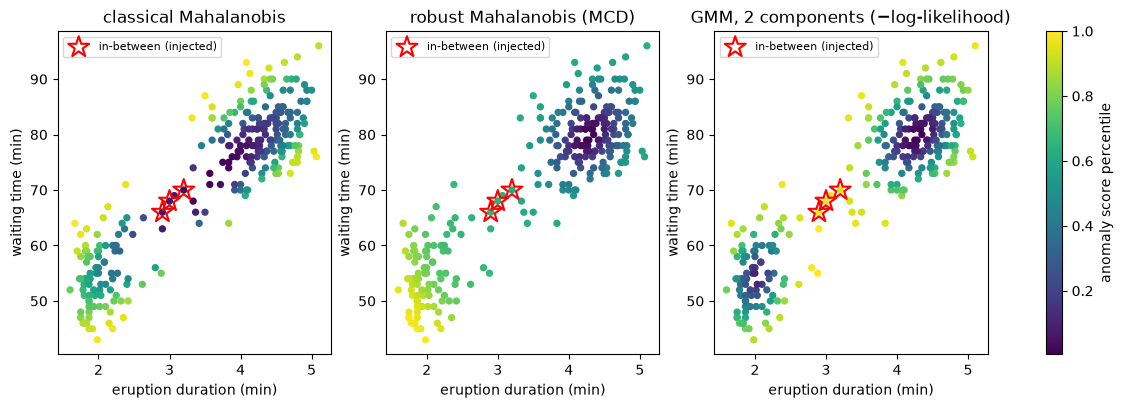

In [8]:
G = geyser[["duration", "waiting"]].to_numpy(float)
between = np.array([[3.0, 68.0], [2.9, 66.0], [3.2, 70.0]])                 # hypothetical, between the two modes
G_all = np.vstack([G, between])
is_between = np.r_[np.zeros(len(G), bool), np.ones(len(between), bool)]
Zg = StandardScaler().fit_transform(G_all)
geyser_scores = {
    "classical Mahalanobis": EmpiricalCovariance().fit(Zg).mahalanobis(Zg),
    "robust Mahalanobis (MCD)": MinCovDet(random_state=SEED).fit(Zg).mahalanobis(Zg),
    "GMM, 2 components (−log-likelihood)": -GaussianMixture(n_components=2, random_state=SEED).fit(Zg).score_samples(Zg),
    "LOF (k=20)": -LocalOutlierFactor(n_neighbors=20).fit(Zg).negative_outlier_factor_,
    "Isolation Forest": -IsolationForest(random_state=SEED).fit(Zg).score_samples(Zg),
}
rank_rows = {}
short_mode = np.r_[(geyser["kind"] == "short").to_numpy(), np.zeros(len(between), bool)]
for name, s in geyser_scores.items():
    ranks = pd.Series(s).rank(ascending=False).to_numpy()
    rank_rows[name] = {"ranks of the 3 in-between eruptions": ranks[is_between].astype(int).tolist(),
                       "short eruptions in the top 30": int((ranks[short_mode] <= 30).sum())}
rank_table = pd.DataFrame(rank_rows).T
print(rank_table.to_string())
mcd_geyser = MinCovDet(random_state=SEED).fit(Zg)
print(f"\nMCD's robust fit covers the {'long' if mcd_geyser.location_[0] > 0 else 'short'} mode; "
      f"{(mcd_geyser.mahalanobis(Zg)[short_mode] > chi2.ppf(0.975, 2)).mean():.0%} of the real short eruptions exceed its χ² cut-off")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, name in zip(axes, ["classical Mahalanobis", "robust Mahalanobis (MCD)", "GMM, 2 components (−log-likelihood)"]):
    sc = ax.scatter(*G_all.T, c=pd.Series(geyser_scores[name]).rank(pct=True), cmap="viridis", s=18)
    ax.scatter(*between.T, marker="*", s=250, facecolor="none", edgecolor="red", linewidth=1.5, label="in-between (injected)")
    ax.set(title=name, xlabel="eruption duration (min)", ylabel="waiting time (min)")
    ax.legend(fontsize=8, loc="upper left")
fig.colorbar(sc, ax=axes, label="anomaly score percentile")
plt.show()

One ellipse puts its centre **in the empty gap between the modes**, so the in-between points look *most* normal to classical Mahalanobis; MCD fits one mode and calls the whole other mode anomalous. A two-component Gaussian mixture models both modes and ranks the in-between eruptions among the most anomalous; LOF and Isolation Forest also rank them far more anomalous than one ellipse does, though not at the very top.

### ✍️ Your Turn

Two points are the same Euclidean distance from the mean `[0, 0]`. With covariance `[[2, 1], [1, 2]]` (positively correlated features), compute the **Mahalanobis distances** of `[1, 1]` and `[1, -1]`.

In [9]:
cov_toy = np.array([[2.0, 1.0], [1.0, 2.0]])
points_toy = np.array([[1.0, 1.0], [1.0, -1.0]])
maha_toy = None  # TODO: array of 2 distances
check("maha_toy", maha_toy, [0.8164966, 1.4142136], hint="np.sqrt(np.sum(points_toy @ np.linalg.inv(cov_toy) * points_toy, axis=1))")

⏳ maha_toy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cov_toy = np.array([[2.0, 1.0], [1.0, 2.0]])
points_toy = np.array([[1.0, 1.0], [1.0, -1.0]])
maha_toy = np.sqrt(np.sum(points_toy @ np.linalg.inv(cov_toy) * points_toy, axis=1))
check("maha_toy", maha_toy, [0.8164966, 1.4142136])
```

`[1, 1]` goes *along* the correlation (common), `[1, -1]` goes *against* it (unusual), so it's farther in Mahalanobis terms although both are √2 away in Euclidean distance. In production prefer `np.linalg.solve` over explicitly inverting.
</details>

> 💡 **Interview angle:** "When do statistical outlier methods fail?" — when the data isn't one Gaussian blob: several modes (the ellipse's centre falls in the gap), heavy tails, categorical features, or when outliers inflate the mean/covariance (use MCD). Mahalanobis handles correlations and gives χ² thresholds when the Gaussian assumption holds.

## 4. Isolation Forest 🟡

**Intuition:** anomalies are **few and different**, so they are **easy to isolate**. Build a tree by repeatedly picking a random feature and a random split value between that feature's min and max. A normal point in a dense crowd needs many cuts before it's alone; an anomaly gets separated after very few.

```
 cut 1 (feature 2 < 0.7)         cut 2 (feature 1 < 3.1)        ★ isolated at depth 2
 ●●●●●●●●●●●●|        ★   →    ●●●●●●●●●●●●|     |★
                                                                a dense ● needs ~8–10 cuts
```

**The math (Liu, Ting & Zhou, 2008):**

- $h(x)$ = the number of edges from the root to the leaf where $x$ lands. If a leaf still holds $m$ training points (the depth limit stopped growth), add $c(m)$, the expected extra depth.
- The average path length of an unsuccessful search in a binary search tree with $n$ points normalizes depths:
  $$c(n) = 2H(n-1) - \frac{2(n-1)}{n},\qquad H(i) \approx \ln(i) + 0.5772156649\ (\text{Euler's constant}),\quad c(2) = 1,\ c(1) = 0$$
- **Anomaly score:** $s(x, \psi) = 2^{-E[h(x)] / c(\psi)}$ over all trees, with $\psi$ = sub-sample size. $s \to 1$: anomaly; $s \approx 0.5$ everywhere: no clear anomalies; $s \ll 0.5$: normal. scikit-learn's `score_samples` returns $-s$ (higher = more normal), so we negate it.

**Why it scales:** each tree is grown on a small random sub-sample ($\psi$ = `max_samples`, 256 by default) with depth limit $\lceil \log_2 \psi \rceil$ = 8. Training cost doesn't grow with n, there are no distance computations, and scoring is O(n · trees · log ψ). The paper also argues that sub-sampling can *improve* accuracy by reducing **swamping** (normals near anomalies mislabelled) and **masking** (too many anomalies hiding each other); the grid below checks that on real data.

**`contamination`** doesn't change the trees or the scores at all. It only sets `offset_`, the threshold used by `predict` (Section 8 proves it).

In [10]:
iso_sat = IsolationForest(n_estimators=300, random_state=SEED).fit(X_sat)
s_sat = -iso_sat.score_samples(X_sat)                                     # s = 2^(−E[h]/c(ψ)) in [0, 1]
c_psi = _average_path_length(np.array([iso_sat.max_samples_]))[0]
mean_depth = -np.log2(s_sat) * c_psi                                      # invert the score formula to recover E[h(x)]
print(f"satellite: ψ = {iso_sat.max_samples_}, c(ψ) = {c_psi:.3f}, depth limit {int(np.ceil(np.log2(iso_sat.max_samples_)))}")
print(f"average isolation depth: anomalies {mean_depth[y_sat == 1].mean():.2f} vs normal points {mean_depth[y_sat == 0].mean():.2f}")
print(f"score s: anomalies median {np.median(s_sat[y_sat == 1]):.3f} vs normal {np.median(s_sat[y_sat == 0]):.3f} | "
      f"ROC-AUC {roc_auc_score(y_sat, s_sat):.3f}, average precision {average_precision_score(y_sat, s_sat):.3f}")

satellite: ψ = 256, c(ψ) = 10.245, depth limit 8
average isolation depth: anomalies 7.57 vs normal points 12.01
score s: anomalies median 0.599 vs normal 0.438 | ROC-AUC 0.951, average precision 0.658


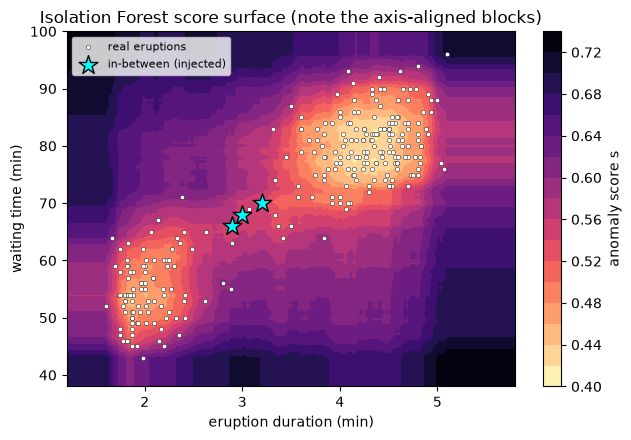

In [11]:
iso_geyser = IsolationForest(random_state=SEED).fit(G_all)
xx, yy = np.meshgrid(np.linspace(1.2, 5.8, 200), np.linspace(38, 100, 200))
grid_scores = -iso_geyser.score_samples(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
contour = ax.contourf(xx, yy, grid_scores, levels=20, cmap="magma_r")
ax.scatter(*G.T, s=10, c="white", edgecolor="k", linewidth=0.3, label="real eruptions")
ax.scatter(*between.T, marker="*", s=200, c="cyan", edgecolor="k", label="in-between (injected)")
fig.colorbar(contour, label="anomaly score s")
ax.set(xlabel="eruption duration (min)", ylabel="waiting time (min)", title="Isolation Forest score surface (note the axis-aligned blocks)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Hyperparameters on real data.** Average precision on satellite for a grid of `n_estimators` × `max_samples`, averaged over 3 random seeds.

In [12]:
iso_grid_rows = []
for n_estimators in [10, 50, 100, 300]:
    for max_samples in [64, 256, 1024, len(X_sat)]:
        aps = [average_precision_score(y_sat, -IsolationForest(n_estimators=n_estimators, max_samples=max_samples, random_state=seed)
                                       .fit(X_sat).score_samples(X_sat)) for seed in range(3)]
        iso_grid_rows.append({"n_estimators": n_estimators, "max_samples": max_samples if max_samples < len(X_sat) else "all (5,100)",
                              "AP": np.mean(aps), "AP std over seeds": np.std(aps)})
iso_grid = pd.DataFrame(iso_grid_rows)
print(iso_grid.pivot(index="n_estimators", columns="max_samples", values="AP").round(3))
print("\nstd across seeds:\n", iso_grid.pivot(index="n_estimators", columns="max_samples", values="AP std over seeds").round(3))
best = iso_grid.loc[iso_grid["AP"].idxmax()]
print(f"\nbest: n_estimators={best['n_estimators']}, max_samples={best['max_samples']} (AP {best['AP']:.3f}); "
      f"more trees mainly reduce seed-to-seed variance: std {iso_grid[iso_grid.n_estimators == 10]['AP std over seeds'].mean():.3f} (10 trees) "
      f"vs {iso_grid[iso_grid.n_estimators == 300]['AP std over seeds'].mean():.3f} (300 trees)")
ap_256 = iso_grid[(iso_grid.n_estimators == 300) & (iso_grid.max_samples == 256)]["AP"].iloc[0]
ap_all = iso_grid[(iso_grid.n_estimators == 300) & (iso_grid.max_samples == "all (5,100)")]["AP"].iloc[0]
print(f"with 300 trees: max_samples=256 AP {ap_256:.3f} vs all rows {ap_all:.3f} → sub-sampling "
      f"{'kept accuracy within 0.02' if ap_256 >= ap_all - 0.02 else 'cost some accuracy here'} while training each tree on "
      f"{len(X_sat) / 256:.0f}× fewer rows")

max_samples      64    256   1024  all (5,100)
n_estimators                                  
10            0.391  0.555  0.575        0.622
50            0.616  0.625  0.628        0.660
100           0.624  0.644  0.641        0.664
300           0.624  0.646  0.647        0.659

std across seeds:
 max_samples      64    256   1024  all (5,100)
n_estimators                                  
10            0.151  0.010  0.037        0.018
50            0.015  0.007  0.023        0.029
100           0.007  0.007  0.017        0.024
300           0.015  0.017  0.024        0.008

best: n_estimators=100, max_samples=all (5,100) (AP 0.664); more trees mainly reduce seed-to-seed variance: std 0.054 (10 trees) vs 0.016 (300 trees)
with 300 trees: max_samples=256 AP 0.646 vs all rows 0.659 → sub-sampling kept accuracy within 0.02 while training each tree on 20× fewer rows


**Why it scales, measured.** Fit and score times on growing numbers of real credit-card transactions, compared with LOF (which needs nearest-neighbour search). The credit-card data contains duplicate rows, which make LOF print a warning; we silence it in this cell only, because here we just measure time (Pitfall 2 explains the warning).

In [13]:
scale_rows = []
Z_credit_all = RobustScaler().fit_transform(X_credit)
for n in [10_000, 50_000, len(X_credit)]:
    subset = Z_credit_all[:n]
    start = time.perf_counter(); iso = IsolationForest(random_state=SEED).fit(subset); fit_s = time.perf_counter() - start
    start = time.perf_counter(); iso.score_samples(subset); score_s = time.perf_counter() - start
    row = {"rows": n, "IsolationForest fit s": fit_s, "IsolationForest score s": score_s}
    if n <= 50_000:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)        # timing only: duplicate rows make LOF warn (see Pitfall 2)
            start = time.perf_counter(); LocalOutlierFactor(n_neighbors=20).fit(subset); row["LOF fit+score s"] = time.perf_counter() - start
    scale_rows.append(row)
scale_table = pd.DataFrame(scale_rows).set_index("rows")
print(scale_table.round(3))
print(f"\n{scale_table.index[-1] / scale_table.index[0]:.0f}× more rows → IsolationForest fit {scale_table['IsolationForest fit s'].iloc[-1] / scale_table['IsolationForest fit s'].iloc[0]:.1f}× "
      f"(sub-sampling), score {scale_table['IsolationForest score s'].iloc[-1] / scale_table['IsolationForest score s'].iloc[0]:.0f}× (linear); "
      f"5× more rows → LOF {scale_table['LOF fit+score s'].iloc[1] / scale_table['LOF fit+score s'].iloc[0]:.0f}× slower")
del Z_credit_all
_ = gc.collect()

        IsolationForest fit s  IsolationForest score s  LOF fit+score s
rows                                                                   
10000                   0.045                    0.019            0.054
50000                   0.069                    0.086            0.478
284807                  0.093                    0.485              NaN

28× more rows → IsolationForest fit 2.1× (sub-sampling), score 26× (linear); 5× more rows → LOF 9× slower


### ✍️ Your Turn

For `max_samples = 256`, compute the normalization constant `c_256` $= 2(\ln(255) + 0.5772156649) - 2 \cdot 255/256$, then the anomaly score `s_depth4` of a point whose average path length is 4.

In [14]:
c_256 = None     # TODO
s_depth4 = None  # TODO
check("c_256", c_256, _average_path_length(np.array([256]))[0], hint="2 * (np.log(255) + 0.5772156649) - 2 * 255 / 256")
check("s_depth4", s_depth4, 2 ** (-4 / _average_path_length(np.array([256]))[0]), hint="2 ** (-4 / c_256)")

⏳ c_256: not attempted yet — replace None with your answer.
⏳ s_depth4: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
c_256 = 2 * (np.log(255) + 0.5772156649) - 2 * 255 / 256
s_depth4 = 2 ** (-4 / c_256)
check("c_256", c_256, _average_path_length(np.array([256]))[0])
check("s_depth4", s_depth4, 2 ** (-4 / _average_path_length(np.array([256]))[0]))
```

c(256) ≈ 10.24: an average point needs about 10 random cuts. Isolated after only 4, the score is ≈ 0.76 > 0.5 → anomalous.
</details>

> 💡 **Interview angle:** "How does Isolation Forest work and why is it fast?" — random trees with random feature/split choices isolate anomalies in short paths; the score is $2^{-E[h]/c(\psi)}$; each tree uses a sub-sample of ~256 points with depth limit ⌈log₂ψ⌉, so training is independent of n and scoring is linear. `contamination` only moves the threshold. Weak spots: local anomalies next to dense clusters and axis-aligned artefacts (Extended Isolation Forest uses random hyperplanes).

## 5. Local Outlier Factor 🟡

**Intuition:** compare each point's **local density** with its neighbours' densities. A point in a sparse region *next to a dense cluster* is suspicious even if a global method thinks it's close enough.

For a chosen $k$ (`n_neighbors`):

1. **k-distance(b)** = distance from $b$ to its k-th nearest neighbour.
2. **Reachability distance** of $a$ from $b$: $\text{reach}_k(a, b) = \max\{\text{k-distance}(b),\ d(a, b)\}$. Inside $b$'s tight neighbourhood, distances are rounded up, which smooths out noise.
3. **Local reachability density:** $\text{lrd}_k(a) = 1 \big/ \Big(\frac{1}{k}\sum_{b \in N_k(a)} \text{reach}_k(a, b)\Big)$.
4. **LOF:** $\text{LOF}_k(a) = \dfrac{\frac{1}{k}\sum_{b \in N_k(a)} \text{lrd}_k(b)}{\text{lrd}_k(a)}$ — the neighbours' average density divided by the point's own. ≈ 1: as dense as its neighbours; ≫ 1: an outlier.

scikit-learn stores $-\text{LOF}$ in `negative_outlier_factor_` (higher = more normal).

**Outlier vs novelty mode.** With `novelty=False` (default) LOF scores the training points themselves and only offers `fit_predict`. With `novelty=True` you fit on (ideally clean) data and call `score_samples`/`predict` on **new** points; don't call them on the training data, where each point would count itself as a neighbour.

In [15]:
lof_rows = []
Z_sat = StandardScaler().fit_transform(X_sat)
for k in [5, 10, 20, 35, 50, 100, 200]:
    scores_k = -LocalOutlierFactor(n_neighbors=k).fit(Z_sat).negative_outlier_factor_
    lof_rows.append({"n_neighbors": k, "ROC-AUC": roc_auc_score(y_sat, scores_k), "average precision": average_precision_score(y_sat, scores_k),
                     "precision@75": precision_at_k(y_sat, scores_k, 75)})
lof_table = pd.DataFrame(lof_rows).set_index("n_neighbors")
print(lof_table.round(3))
print(f"\nsatellite has {y_sat.sum()} anomalies; n_neighbors={lof_table['average precision'].idxmax()} gives the best AP. "
      f"Too small a k lets a small group of similar anomalies be each other's neighbours, so they look 'dense'.")

             ROC-AUC  average precision  precision@75
n_neighbors                                          
5              0.738              0.211         0.293
10             0.762              0.205         0.227
20             0.676              0.187         0.253
35             0.889              0.205         0.280
50             0.969              0.359         0.333
100            0.971              0.638         0.547
200            0.962              0.615         0.560

satellite has 75 anomalies; n_neighbors=100 gives the best AP. Too small a k lets a small group of similar anomalies be each other's neighbours, so they look 'dense'.


**Novelty mode on cardiotocography.** Semi-supervised: fit on the **normal** recordings of a training split, then score the unseen test split, and compare with fitting on the contaminated training split.

In [16]:
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_ctg, y_ctg, test_size=0.5, stratify=y_ctg, random_state=SEED)
ctg_scaler = StandardScaler().fit(Xc_tr[yc_tr == 0])
Zc_tr, Zc_te = ctg_scaler.transform(Xc_tr), ctg_scaler.transform(Xc_te)
novelty_rows = {}
for name, train_rows in [("fit on normal training rows only", yc_tr == 0), ("fit on all (contaminated) training rows", np.ones(len(yc_tr), bool))]:
    lof_nov = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(Zc_tr[train_rows])
    s = -lof_nov.score_samples(Zc_te)
    flagged = lof_nov.predict(Zc_te) == -1
    novelty_rows[name] = {"test ROC-AUC": roc_auc_score(yc_te, s), "test AP": average_precision_score(yc_te, s),
                          "flagged by predict": flagged.mean(), "precision of flags": yc_te[flagged].mean() if flagged.any() else np.nan}
print(pd.DataFrame(novelty_rows).T.round(3))
print(f"test anomaly rate: {yc_te.mean():.1%}")

                                         test ROC-AUC  test AP  flagged by predict  precision of flags
fit on normal training rows only                0.911    0.559               0.055                0.62
fit on all (contaminated) training rows         0.527    0.133               0.027                0.24
test anomaly rate: 9.6%


### ✍️ Your Turn

A point's local reachability density is `0.2`; its 2 neighbours have densities `1.0` and `0.8`. Compute its **LOF**.

In [17]:
lrd_point, lrd_neighbours = 0.2, np.array([1.0, 0.8])
lof_value = None  # TODO: your code here
check("lof_value", lof_value, 4.5, hint="mean of the neighbours' lrd divided by the point's lrd")

⏳ lof_value: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
lrd_point, lrd_neighbours = 0.2, np.array([1.0, 0.8])
lof_value = lrd_neighbours.mean() / lrd_point
check("lof_value", lof_value, 4.5)
```

Its neighbours are 4.5× denser than it is → a clear local outlier.
</details>

> 💡 **Interview angle:** "LOF vs Isolation Forest?" — LOF compares local densities, so it finds points that are sparse *relative to their neighbourhood* (good with clusters of different density) but costs O(n²) neighbour searches, is sensitive to `n_neighbors` and breaks on duplicates. Isolation Forest is global, much faster and a stronger default on large tabular data. Use `novelty=True` to score new data with LOF.

## 6. One-Class SVM, GMM Scores and PCA Reconstruction Error 🟡

Three more families, each best in the **semi-supervised** setting (train on normal data):

| Method | Idea | Anomaly score |
|---|---|---|
| **One-Class SVM** | map data with an RBF kernel and find the maximum-margin boundary that separates it from the origin; `nu` ∈ (0, 1] is an upper bound on the fraction of training points outside and a lower bound on the fraction of support vectors | `-score_samples` (distance outside the boundary) |
| **Gaussian Mixture density** | fit a mixture of Gaussians ([Notebook 13](13_Clustering_DBSCAN_and_Gaussian_Mixtures.ipynb)); low probability density = anomalous | $-\log p(x)$ = `-score_samples` |
| **PCA reconstruction error** | normal data lives near a low-dimensional subspace ([Notebook 14](14_Dimensionality_Reduction_PCA_tSNE_UMAP.ipynb)); anomalies don't fit it | $\lVert x - \hat x\rVert^2$ after `inverse_transform(transform(x))` |

**Scaling One-Class SVM.** A kernel SVM needs time between O(n²) and O(n³) to fit, and scoring touches every support vector. `SGDOneClassSVM` solves the *linear* version with stochastic gradient descent in O(n); put a `Nystroem` kernel approximation in front to recover an approximate RBF kernel. We measure both on real credit-card transactions: fit on normal transactions from the first 60% of the (time-ordered) data, score the next 20%.

In [18]:
n_credit = len(X_credit)
cut_val, cut_test = int(0.6 * n_credit), int(0.8 * n_credit)
train_rows, val_rows, test_rows = np.arange(cut_val), np.arange(cut_val, cut_test), np.arange(cut_test, n_credit)
normal_train_pool = train_rows[y_credit[train_rows] == 0]
credit_normal_fit = rng.choice(normal_train_pool, size=50_000, replace=False)    # subsample of normal history, for speed
credit_scaler = RobustScaler().fit(X_credit[credit_normal_fit])
C_val, y_val = credit_scaler.transform(X_credit[val_rows]), y_credit[val_rows]
print(f"time-ordered split: train {len(train_rows):,} rows ({y_credit[train_rows].sum()} frauds) | validation {len(val_rows):,} "
      f"({y_val.sum()} frauds) | test {len(test_rows):,} ({y_credit[test_rows].sum()} frauds)")

svm_rows = []
for n in [5_000, 20_000, 50_000]:
    C_fit = credit_scaler.transform(X_credit[credit_normal_fit[:n]])
    models = {"OneClassSVM (RBF)": OneClassSVM(nu=0.05, gamma="scale"),
              "Nystroem(300) + SGDOneClassSVM": make_pipeline(Nystroem(n_components=300, random_state=SEED), SGDOneClassSVM(nu=0.05, random_state=SEED))}
    for name, model in models.items():
        if name.startswith("OneClassSVM") and n > 20_000:
            continue                                             # the kernel SVM gets slow; that's the point
        start = time.perf_counter(); model.fit(C_fit); fit_s = time.perf_counter() - start
        start = time.perf_counter(); s = -model.score_samples(C_val); score_s = time.perf_counter() - start
        svm_rows.append({"model": name, "normal rows": n, "fit s": fit_s, f"score s ({len(C_val):,} rows)": score_s,
                         "val ROC-AUC": roc_auc_score(y_val, s), "val AP": average_precision_score(y_val, s)})
svm_table = pd.DataFrame(svm_rows).set_index(["model", "normal rows"])
print(svm_table.round(4))
kernel_fit = svm_table.loc["OneClassSVM (RBF)", "fit s"]
print(f"\nOneClassSVM fit time grew {kernel_fit.iloc[-1] / kernel_fit.iloc[0]:.1f}× for 4× the rows; "
      f"the SGD version scored {len(C_val):,} rows in {svm_table.loc[('Nystroem(300) + SGDOneClassSVM', 50_000)].iloc[1]:.2f}s at 50k training rows")

time-ordered split: train 170,884 rows (360 frauds) | validation 56,961 (57 frauds) | test 56,962 (75 frauds)


                                             fit s  score s (56,961 rows)  val ROC-AUC  val AP
model                          normal rows                                                    
OneClassSVM (RBF)              5000         0.0251                 0.4013       0.9336  0.0255
Nystroem(300) + SGDOneClassSVM 5000         0.0200                 0.0891       0.9270  0.0147
OneClassSVM (RBF)              20000        0.3360                 1.3403       0.9326  0.0262
Nystroem(300) + SGDOneClassSVM 20000        0.0659                 0.0836       0.9295  0.0148
                               50000        0.1417                 0.0760       0.9303  0.0177

OneClassSVM fit time grew 13.4× for 4× the rows; the SGD version scored 56,961 rows in 0.08s at 50k training rows


**Density and reconstruction scores on cardiotocography** (same semi-supervised split as Section 5). The GMM's number of components is chosen by **BIC** on the normal training rows; `reg_covar=1e-3` keeps the 21-dimensional covariances well-conditioned. PCA keeps 90% of the normal data's variance.

In [19]:
Zc_norm = Zc_tr[yc_tr == 0]
bic = {k: GaussianMixture(n_components=k, reg_covar=1e-3, random_state=SEED).fit(Zc_norm).bic(Zc_norm) for k in range(1, 6)}
best_k = min(bic, key=bic.get)
gmm = GaussianMixture(n_components=best_k, reg_covar=1e-3, random_state=SEED).fit(Zc_norm)
pca_det = PCA(n_components=0.9, random_state=SEED).fit(Zc_norm)
semi_scores = {
    f"GMM ({best_k} components by BIC)": -gmm.score_samples(Zc_te),
    f"PCA reconstruction ({pca_det.n_components_} comps)": ((Zc_te - pca_det.inverse_transform(pca_det.transform(Zc_te))) ** 2).sum(axis=1),
    "OneClassSVM (nu=0.05)": -OneClassSVM(nu=0.05, gamma="scale").fit(Zc_norm).score_samples(Zc_te),
    "IsolationForest": -IsolationForest(n_estimators=300, random_state=SEED).fit(Zc_norm).score_samples(Zc_te),
}
print("BIC by number of components:", {k: round(v) for k, v in bic.items()})
semi_table = pd.DataFrame({name: {"test ROC-AUC": roc_auc_score(yc_te, s), "test AP": average_precision_score(yc_te, s),
                                  f"precision@{yc_te.sum()}": precision_at_k(yc_te, s, yc_te.sum())}
                           for name, s in semi_scores.items()}).T.sort_values("test AP", ascending=False)
print(semi_table.round(3))
print(f"\nbest on this split: {semi_table.index[0]}")

BIC by number of components: {1: 27427, 2: 16722, 3: 16357, 4: 14022, 5: 13577}
                               test ROC-AUC  test AP  precision@88
OneClassSVM (nu=0.05)                 0.983    0.865         0.773
IsolationForest                       0.942    0.649         0.568
GMM (5 components by BIC)             0.811    0.649         0.659
PCA reconstruction (11 comps)         0.902    0.562         0.557

best on this split: OneClassSVM (nu=0.05)


### ✍️ Your Turn

A PCA detector has mean `[1, 1]` and one component `[0.6, 0.8]`. Compute the **squared reconstruction error** of the point `[3, 4]`.

In [20]:
mean_toy, component_toy, point_toy = np.array([1.0, 1.0]), np.array([0.6, 0.8]), np.array([3.0, 4.0])
recon_error_toy = None  # TODO: your code here
check("recon_error_toy", recon_error_toy, 0.04, hint="c = point - mean; z = c @ component; error = ((c - z * component) ** 2).sum()")

⏳ recon_error_toy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mean_toy, component_toy, point_toy = np.array([1.0, 1.0]), np.array([0.6, 0.8]), np.array([3.0, 4.0])
centered = point_toy - mean_toy                     # [2, 3]
z = centered @ component_toy                         # 3.6
recon_error_toy = ((centered - z * component_toy) ** 2).sum()
check("recon_error_toy", recon_error_toy, 0.04)
```

The reconstruction is `[2.16, 2.88]` (centered), leaving a residual of `[-0.16, 0.12]` off the component line: squared length 0.04. A point far off the normal subspace would have a large residual.
</details>

> 💡 **Interview angle:** "Which detector for a clean 'normal-only' training set?" — novelty methods: One-Class SVM (small/medium n; `nu` ≈ expected outlier fraction; `SGDOneClassSVM` + `Nystroem` for big n), density models (GMM log-likelihood, KDE), reconstruction error (PCA, autoencoders), or Isolation Forest/LOF fitted on the clean data. Compare them on a labelled validation sample.

## 7. PyOD: One Interface, Many Detectors 🟡

**PyOD** wraps dozens of detectors behind one API, so trying many is cheap:

| Attribute / method | Meaning |
|---|---|
| `fit(X)` | fit on (unlabelled) data |
| `decision_scores_` | anomaly scores of the training data (**higher = more anomalous**, unlike scikit-learn's `score_samples`) |
| `decision_function(X)` | scores for new data |
| `threshold_`, `labels_` | the score cut-off implied by `contamination`, and the 0/1 training labels |
| `predict(X)` | 0 = inlier, 1 = outlier (not ±1 as in scikit-learn) |
| `predict_proba(X, method="linear" or "unify")` | scores rescaled into an outlier probability |

A few detectors worth knowing:

- **ECOD** (Empirical-CDF-based): per feature, how far into the tails is this value? Sum the −log tail probabilities. No hyperparameters, very fast.
- **COPOD** (Copula-based): similar tail probabilities, combined through an empirical copula.
- **HBOS** (Histogram-based): per-feature histograms, assumes independent features; extremely fast.
- **KNN**: distance to the k-th nearest neighbour (or the mean of the k distances).
- **AutoEncoder** (PyTorch): reconstruction error of a small neural network; here on the CPU with 30 epochs.

We use the cardiotocography data in the **unsupervised** setting: fit on a contaminated 60% split, score the other 40%.

In [21]:
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_ctg, y_ctg, test_size=0.4, stratify=y_ctg, random_state=SEED)
pyod_scaler = StandardScaler().fit(Xp_tr)
Zp_tr, Zp_te = pyod_scaler.transform(Xp_tr), pyod_scaler.transform(Xp_te)
pyod_detectors = {
    "ECOD": ECOD(contamination=0.1),
    "COPOD": COPOD(contamination=0.1),
    "HBOS": HBOS(contamination=0.1),
    "KNN (k=10)": KNN(n_neighbors=10, contamination=0.1),
    "IForest": IForest(n_estimators=300, random_state=SEED, contamination=0.1),
    "LOF (k=20)": LOF(n_neighbors=20, contamination=0.1),
    "AutoEncoder (CPU, 30 epochs)": AutoEncoder(epoch_num=30, batch_size=64, hidden_neuron_list=[32, 16], verbose=0,
                                                device="cpu", random_state=SEED, contamination=0.1),
}
pyod_rows, train_scores, test_scores = {}, {}, {}
for name, detector in pyod_detectors.items():
    start = time.perf_counter()
    detector.fit(Zp_tr)                                   # (in pyod 3.x some detectors' fit returns None, so don't chain it)
    fit_s = time.perf_counter() - start
    train_scores[name], test_scores[name] = detector.decision_scores_, detector.decision_function(Zp_te)
    pyod_rows[name] = {"test ROC-AUC": roc_auc_score(yp_te, test_scores[name]), "test AP": average_precision_score(yp_te, test_scores[name]),
                       "flagged by predict": detector.predict(Zp_te).mean(), "fit s": fit_s}
pyod_table = pd.DataFrame(pyod_rows).T.sort_values("test AP", ascending=False)
print(pyod_table.round(3))

ecod = pyod_detectors["ECOD"]
print(f"\nECOD threshold_ = {ecod.threshold_:.2f} → training share above it {ecod.labels_.mean():.1%} (= contamination 10%)")
print("ECOD predict_proba (linear) for 3 test rows:\n", ecod.predict_proba(Zp_te[:3]).round(3))

                              test ROC-AUC  test AP  flagged by predict  fit s
ECOD                                 0.935    0.600               0.093  0.190
IForest                              0.928    0.580               0.085  0.120
COPOD                                0.918    0.573               0.098  0.002
HBOS                                 0.850    0.452               0.104  0.668
KNN (k=10)                           0.761    0.380               0.086  0.004
AutoEncoder (CPU, 30 epochs)         0.827    0.363               0.091  1.500
LOF (k=20)                           0.560    0.164               0.086  0.003

ECOD threshold_ = 36.70 → training share above it 10.0% (= contamination 10%)
ECOD predict_proba (linear) for 3 test rows:
 [[0.744 0.256]
 [0.408 0.592]
 [0.797 0.203]]


**Combining detectors.** Raw scores live on different scales (ECOD sums log-probabilities, KNN returns distances), so **standardize** each detector's scores using its *training* score mean and standard deviation (`pyod.utils.utility.standardizer`), then combine: **average** (stable), **maximum** (sensitive), or **average of maximum** (AOM: max within random buckets of detectors, then average). PyOD's own `pyod.models.combination` module needs the extra `combo` package, which isn't installed here, so we write the three one-line combinations ourselves.

In [22]:
names = list(pyod_detectors)
train_matrix = np.column_stack([train_scores[n] for n in names])
test_matrix = np.column_stack([test_scores[n] for n in names])
train_std, test_std = standardizer(train_matrix, test_matrix)          # z-scores using the TRAINING score statistics
buckets = np.array_split(np.random.default_rng(SEED).permutation(len(names)), 3)
combinations = {"average of standardized scores": test_std.mean(axis=1),
                "maximum of standardized scores": test_std.max(axis=1),
                "average of maximum (3 buckets)": np.mean([test_std[:, b].max(axis=1) for b in buckets], axis=0)}
combo_table = pd.DataFrame({name: {"test ROC-AUC": roc_auc_score(yp_te, s), "test AP": average_precision_score(yp_te, s)}
                            for name, s in combinations.items()}).T
print(combo_table.round(3))
print(f"\nbest single detector AP {pyod_table['test AP'].max():.3f} ({pyod_table['test AP'].idxmax()}) | median single detector AP "
      f"{pyod_table['test AP'].median():.3f} | average combination AP {combo_table.loc['average of standardized scores', 'test AP']:.3f}")
avg_ap = combo_table.loc["average of standardized scores", "test AP"]
print(f"→ the average ensemble {'beat' if avg_ap > pyod_table['test AP'].median() else 'did not beat'} the median single detector and "
      f"{'beat' if avg_ap > pyod_table['test AP'].max() else 'did not beat'} the best one → "
      + ("without labels to find the best detector, an ensemble is a safer choice than picking one blindly"
         if avg_ap >= pyod_table['test AP'].median() else
         "an ensemble isn't automatically safer: weak detectors drag the average down, so drop detectors that disagree with the rest"))

                                test ROC-AUC  test AP
average of standardized scores         0.912    0.484
maximum of standardized scores         0.933    0.529
average of maximum (3 buckets)         0.930    0.520

best single detector AP 0.600 (ECOD) | median single detector AP 0.452 | average combination AP 0.484
→ the average ensemble beat the median single detector and did not beat the best one → without labels to find the best detector, an ensemble is a safer choice than picking one blindly


> 💡 **Interview angle:** "You have no labels. Which detector do you ship?" — try several diverse, fast detectors (PyOD makes it one loop), standardize their scores on training data and average them (robust ensemble), then get a small labelled sample by having analysts review the top-k to validate. ECOD/COPOD are parameter-free baselines; Isolation Forest is a strong default.

## 8. Evaluating With Few Labels 🔴

This section decides whether an anomaly project succeeds. We score the credit-card **validation period** with an Isolation Forest fitted on 50,000 normal transactions from the training period.

| Metric | What it answers | Behaviour at 0.1% positives |
|---|---|---|
| **Accuracy** | share of correct labels | ≈ 99.9% for a model that does nothing: **useless** |
| **ROC-AUC** | P(random anomaly scores above random normal) | can look great (above 0.9) while the top of the list is mostly false alarms, because false-positive *rate* divides by a huge number of normals |
| **Average precision (PR-AUC)** | average precision over recall levels | random baseline = the anomaly rate; sensitive to the top of the ranking |
| **precision@k / recall@k** | of the k cases an analyst reviews, how many are real; what share of all anomalies they catch | maps directly to a review budget |

anomaly rate (random AP baseline)   0.0010
accuracy: always normal             0.9990
accuracy: IsolationForest.predict   0.9510
share flagged by predict            0.0496
ROC-AUC                             0.9393
average precision                   0.0243

ROC-AUC looks strong (0.939) while average precision is 0.024: 24× better than random, but most top-ranked cases are still false alarms.

                     precision@k  recall@k  frauds found
k (cases reviewed)                                     
50                        0.020     0.018             1
100                       0.010     0.018             1
200                       0.015     0.053             3
500                       0.030     0.263            15
1000                      0.027     0.474            27
5000                      0.010     0.877            50


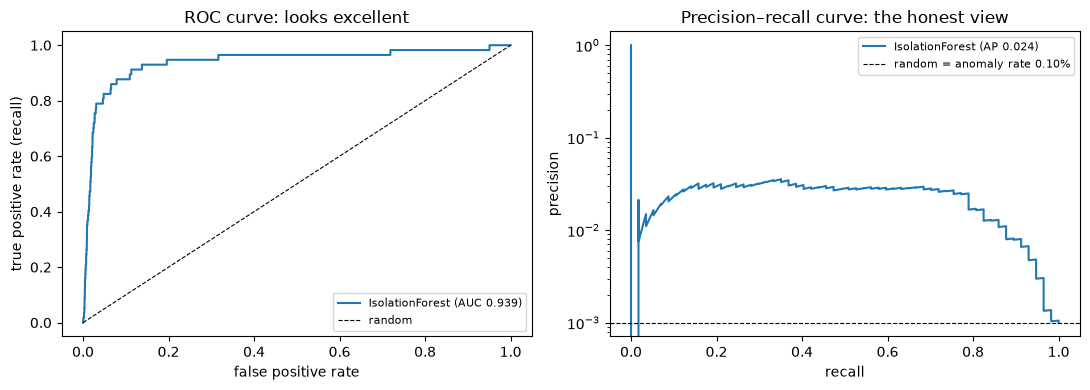

In [23]:
C_fit50 = credit_scaler.transform(X_credit[credit_normal_fit])
iso_credit = IsolationForest(n_estimators=300, random_state=SEED).fit(C_fit50)
val_scores = -iso_credit.score_samples(C_val)
iso_pred = iso_credit.predict(C_val) == -1                               # contamination="auto" threshold
eval_summary = {
    "anomaly rate (random AP baseline)": y_val.mean(),
    "accuracy: always normal": accuracy_score(y_val, np.zeros_like(y_val)),
    "accuracy: IsolationForest.predict": accuracy_score(y_val, iso_pred.astype(int)),
    "share flagged by predict": iso_pred.mean(),
    "ROC-AUC": roc_auc_score(y_val, val_scores),
    "average precision": average_precision_score(y_val, val_scores),
}
print(pd.Series(eval_summary).to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nROC-AUC looks strong ({eval_summary['ROC-AUC']:.3f}) while average precision is {eval_summary['average precision']:.3f}: "
      f"{eval_summary['average precision'] / y_val.mean():.0f}× better than random, but most top-ranked cases are still false alarms.")

k_rows = [{"k (cases reviewed)": k, "precision@k": precision_at_k(y_val, val_scores, k), "recall@k": recall_at_k(y_val, val_scores, k),
           "frauds found": int(round(precision_at_k(y_val, val_scores, k) * k))} for k in [50, 100, 200, 500, 1_000, 5_000]]
print("\n", pd.DataFrame(k_rows).set_index("k (cases reviewed)").round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(y_val, val_scores)
axes[0].plot(fpr, tpr, label=f"IsolationForest (AUC {eval_summary['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="random")
axes[0].set(xlabel="false positive rate", ylabel="true positive rate (recall)", title="ROC curve: looks excellent")
prec, rec, _ = precision_recall_curve(y_val, val_scores)
axes[1].plot(rec, prec, label=f"IsolationForest (AP {eval_summary['average precision']:.3f})")
axes[1].axhline(y_val.mean(), c="k", ls="--", lw=0.8, label=f"random = anomaly rate {y_val.mean():.2%}")
axes[1].set(xlabel="recall", ylabel="precision", title="Precision–recall curve: the honest view", yscale="log")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**`contamination` is a threshold, not a model parameter.** Same data, same `random_state`, three contamination values:

In [24]:
contam_rows = []
for contamination in ["auto", 0.001, 0.01, 0.05]:
    model = IsolationForest(n_estimators=300, contamination=contamination, random_state=SEED).fit(C_fit50)
    assert np.array_equal(model.score_samples(C_val), iso_credit.score_samples(C_val))      # identical trees and scores
    flags = model.predict(C_val) == -1
    contam_rows.append({"contamination": contamination, "offset_ (threshold)": model.offset_, "flagged share": flags.mean(),
                        "precision of flags": y_val[flags].mean() if flags.any() else np.nan,
                        "recall of flags": y_val[flags].sum() / y_val.sum(),
                        "AP (uses scores)": average_precision_score(y_val, -model.score_samples(C_val))})
print(pd.DataFrame(contam_rows).set_index("contamination").round(4))
print("✅ score_samples are identical for every contamination value; only offset_ and therefore predict change.")

               offset_ (threshold)  flagged share  precision of flags  recall of flags  AP (uses scores)
contamination                                                                                           
auto                       -0.5000         0.0496              0.0166           0.8246            0.0243
0.001                      -0.6759         0.0012              0.0145           0.0175            0.0243
0.01                       -0.5801         0.0137              0.0295           0.4035            0.0243
0.05                       -0.4857         0.0640              0.0129           0.8246            0.0243
✅ score_samples are identical for every contamination value; only offset_ and therefore predict change.


**Choosing a threshold from a review budget, without peeking.** Suppose analysts can review **250 cases per half-period**. Pick the threshold on the *first half* of the validation period (the 250th highest score), then apply that fixed threshold to the *second half*. The number of alerts will not be exactly 250, because score distributions drift.

In [25]:
half = len(val_rows) // 2
first_scores, second_scores = val_scores[:half], val_scores[half:]
first_y, second_y = y_val[:half], y_val[half:]
budget = 250
threshold = np.sort(first_scores)[::-1][budget - 1]
flags_second = second_scores >= threshold
print(f"threshold set on the first half: s ≥ {threshold:.4f} (exactly {budget} alerts there, precision {first_y[first_scores >= threshold].mean():.2f})")
print(f"applied to the second half: {flags_second.sum()} alerts (budget {budget}), precision {second_y[flags_second].mean():.2f}, "
      f"recall {second_y[flags_second].sum() / second_y.sum():.2f}")
print(f"top-{budget} queue on the second half instead (always exactly {budget}): precision {precision_at_k(second_y, second_scores, budget):.2f}, "
      f"recall {recall_at_k(second_y, second_scores, budget):.2f}")

threshold set on the first half: s ≥ 0.6067 (exactly 250 alerts there, precision 0.01)
applied to the second half: 233 alerts (budget 250), precision 0.05, recall 0.36
top-250 queue on the second half instead (always exactly 250): precision 0.05, recall 0.36


**Few labels means wide error bars.** The validation period has only a few dozen frauds, so metrics are noisy. A **bootstrap** (resample the rows with replacement many times, recompute the metric) shows how noisy.

In [26]:
boot_rng = np.random.default_rng(SEED)
boot_ap, boot_p100 = [], []
for _ in range(300):
    idx = boot_rng.integers(0, len(y_val), len(y_val))
    if y_val[idx].sum() == 0:
        continue
    boot_ap.append(average_precision_score(y_val[idx], val_scores[idx]))
    boot_p100.append(precision_at_k(y_val[idx], val_scores[idx], 100))
print(f"{y_val.sum()} frauds in validation | AP {eval_summary['average precision']:.3f}, 95% bootstrap interval "
      f"[{np.percentile(boot_ap, 2.5):.3f}, {np.percentile(boot_ap, 97.5):.3f}] | precision@100 {precision_at_k(y_val, val_scores, 100):.2f}, "
      f"interval [{np.percentile(boot_p100, 2.5):.2f}, {np.percentile(boot_p100, 97.5):.2f}]")

57 frauds in validation | AP 0.024, 95% bootstrap interval [0.017, 0.038] | precision@100 0.01, interval [0.00, 0.04]


**Practical ways to get labels:** analysts' decisions on the reviewed top-k (precision@k is measurable without labelling everything), chargebacks that arrive later, injected synthetic anomalies for sanity checks (not for final metrics), and a small random audit sample to estimate recall (what the queue misses).

### ✍️ Your Turn

Compute **recall@2**: the share of all true anomalies that appear in the 2 highest-scored cases.

In [27]:
scores_toy = np.array([0.9, 0.1, 0.8, 0.3, 0.7, 0.2])
labels_toy = np.array([1, 0, 0, 0, 1, 1])
recall_at_2 = None  # TODO: your code here (without the helper)
check("recall_at_2", recall_at_2, 1 / 3, hint="top = np.argsort(-scores_toy)[:2]; labels_toy[top].sum() / labels_toy.sum()")

⏳ recall_at_2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
scores_toy = np.array([0.9, 0.1, 0.8, 0.3, 0.7, 0.2])
labels_toy = np.array([1, 0, 0, 0, 1, 1])
top = np.argsort(-scores_toy)[:2]
recall_at_2 = labels_toy[top].sum() / labels_toy.sum()
check("recall_at_2", recall_at_2, 1 / 3)
```

The top 2 are rows 0 (anomaly) and 2 (normal): 1 of the 3 anomalies found. precision@2 would be 1/2.
</details>

> 💡 **Interview angle:** "How do you evaluate an anomaly detector with very few labels?" — rank-based metrics that match the decision: precision@k for the review budget, PR-AUC/average precision (baseline = prevalence) rather than ROC-AUC or accuracy; bootstrap intervals because positives are few; thresholds chosen on validation data from the budget (contamination is just a threshold); and label collection through analyst feedback and random audits.

## 9. A Fair Head-to-Head Across Real Datasets 🟡

**Protocol (identical for every detector and dataset):** stratified 5-fold split; on each fold, fit a `StandardScaler` and the detector on the 4 training folds **without labels** (unsupervised, contaminated), score the held-out fold, then compute average precision, ROC-AUC, **precision@k with k = the number of anomalies in the fold** (R-precision) and fit/score times. Labels are used only for grading.

In [28]:
def pca_reconstruction_scores(model, Z):
    return ((Z - model.inverse_transform(model.transform(Z))) ** 2).sum(axis=1)


DETECTORS = {                                  # name → (factory, how to turn a fitted model into anomaly scores)
    "IsolationForest": (lambda: IsolationForest(n_estimators=300, random_state=SEED), lambda m, Z: -m.score_samples(Z)),
    "LOF (k=20, novelty)": (lambda: LocalOutlierFactor(n_neighbors=20, novelty=True), lambda m, Z: -m.score_samples(Z)),
    "OneClassSVM (nu=0.1)": (lambda: OneClassSVM(nu=0.1, gamma="scale"), lambda m, Z: -m.score_samples(Z)),
    "GMM (3 components)": (lambda: GaussianMixture(n_components=3, reg_covar=1e-3, random_state=SEED), lambda m, Z: -m.score_samples(Z)),
    "PCA reconstruction (90%)": (lambda: PCA(n_components=0.9, random_state=SEED), pca_reconstruction_scores),
    "ECOD": (lambda: ECOD(), lambda m, Z: m.decision_function(Z)),
    "COPOD": (lambda: COPOD(), lambda m, Z: m.decision_function(Z)),
    "HBOS": (lambda: HBOS(), lambda m, Z: m.decision_function(Z)),
    "KNN (k=10)": (lambda: KNN(n_neighbors=10), lambda m, Z: m.decision_function(Z)),
}
benchmark_sets = {"satellite": (X_sat, y_sat), "annthyroid": (X_thy, y_thy), "cardiotocography": (X_ctg, y_ctg)}
bench_rows = []
for data_name, (X, y) in benchmark_sets.items():
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    for fold, (tr, te) in enumerate(folds.split(X, y)):
        scaler = StandardScaler().fit(X[tr])
        Z_tr, Z_te = scaler.transform(X[tr]), scaler.transform(X[te])
        for det_name, (factory, scorer) in DETECTORS.items():
            model = factory()
            start = time.perf_counter(); model.fit(Z_tr); fit_ms = (time.perf_counter() - start) * 1000
            start = time.perf_counter(); s = scorer(model, Z_te); score_ms = (time.perf_counter() - start) * 1000
            bench_rows.append({"dataset": data_name, "detector": det_name, "fold": fold, "AP": average_precision_score(y[te], s),
                               "ROC-AUC": roc_auc_score(y[te], s), "precision@k": precision_at_k(y[te], s, int(y[te].sum())),
                               "fit ms": fit_ms, "score ms": score_ms})
bench = pd.DataFrame(bench_rows)
per_dataset = bench.groupby(["dataset", "detector"])[["AP", "ROC-AUC", "precision@k", "fit ms", "score ms"]].mean()
for data_name in benchmark_sets:
    print(f"\n=== {data_name} (anomaly rate {benchmark_sets[data_name][1].mean():.1%}) ===")
    print(per_dataset.loc[data_name].sort_values("AP", ascending=False).round(3))


=== satellite (anomaly rate 1.5%) ===
                             AP  ROC-AUC  precision@k   fit ms  score ms
detector                                                                
IsolationForest           0.669    0.951        0.627  100.741    14.293
OneClassSVM (nu=0.1)      0.625    0.916        0.547   29.374    10.685
HBOS                      0.559    0.919        0.533    4.485     0.687
KNN (k=10)                0.546    0.974        0.493   13.749     3.455
COPOD                     0.525    0.906        0.493   11.119    14.261
ECOD                      0.443    0.875        0.467   11.135    14.332
GMM (3 components)        0.311    0.939        0.293   33.951     0.323
LOF (k=20, novelty)       0.203    0.686        0.267   16.825     4.775
PCA reconstruction (90%)  0.175    0.823        0.187    0.382     0.138

=== annthyroid (anomaly rate 7.5%) ===
                             AP  ROC-AUC  precision@k   fit ms  score ms
detector                                     

                          mean AP  mean rank (1 = best)  worst rank  mean ROC-AUC  mean fit+score ms
detector                                                                                            
IsolationForest             0.532                 2.000         3.0         0.906            117.942
ECOD                        0.445                 3.667         6.0         0.874             12.059
COPOD                       0.438                 4.000         6.0         0.877             12.038
HBOS                        0.438                 4.000         5.0         0.815              2.622
KNN (k=10)                  0.390                 4.667         6.0         0.839             16.682
OneClassSVM (nu=0.1)        0.397                 4.667         7.0         0.806             21.552
GMM (3 components)          0.334                 5.333         8.0         0.861             20.194
LOF (k=20, novelty)         0.184                 8.333         9.0         0.656          

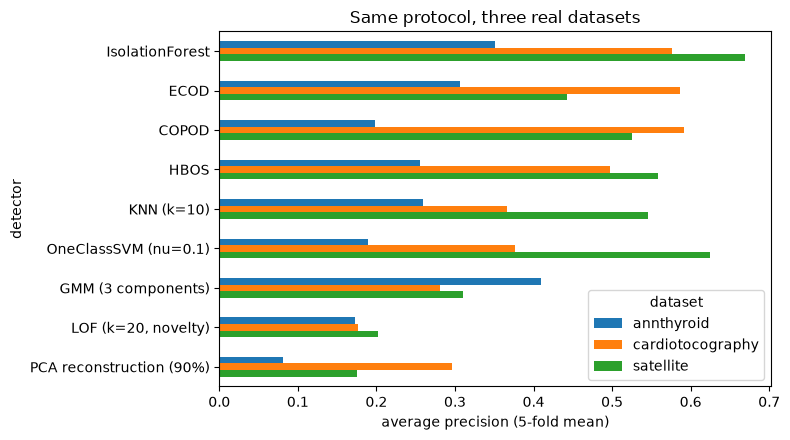

In [29]:
ap_matrix = per_dataset["AP"].unstack("dataset")
rank_matrix = ap_matrix.rank(ascending=False)
summary = pd.DataFrame({"mean AP": ap_matrix.mean(axis=1), "mean rank (1 = best)": rank_matrix.mean(axis=1),
                        "worst rank": rank_matrix.max(axis=1), "mean ROC-AUC": per_dataset["ROC-AUC"].unstack("dataset").mean(axis=1),
                        "mean fit+score ms": (per_dataset["fit ms"] + per_dataset["score ms"]).unstack("dataset").mean(axis=1)}
                       ).sort_values("mean rank (1 = best)")
print(summary.round(3))
winners = ap_matrix.idxmax()
print(f"\nwinner per dataset (AP): {winners.to_dict()}")
print(f"best mean rank: {summary.index[0]} ({summary.iloc[0]['mean rank (1 = best)']:.1f}); most consistent (best worst-rank): "
      f"{summary['worst rank'].idxmin()} (never below rank {summary['worst rank'].min():.0f}); fastest: {summary['mean fit+score ms'].idxmin()}")
print(f"{'different datasets have different winners' if winners.nunique() > 1 else 'one detector won every dataset'} → "
      f"{'no single detector dominates: benchmark on your own data' if winners.nunique() > 1 else 'but check more datasets before generalizing'}.")
fold_std = bench.groupby(["dataset", "detector"])["AP"].std().groupby("dataset").mean()
print(f"average fold-to-fold AP std per dataset: {fold_std.round(3).to_dict()} → differences smaller than this are noise")

fig, ax = plt.subplots(figsize=(8, 4.5))
ap_matrix.loc[summary.index].plot.barh(ax=ax)
ax.invert_yaxis()
ax.set(xlabel="average precision (5-fold mean)", title="Same protocol, three real datasets")
plt.tight_layout()
plt.show()

Large benchmarks such as ADBench (57 datasets) reach the same headline: **no unsupervised detector is best everywhere**, and even a small number of labels (semi-supervised or supervised methods) usually helps a lot.

> 💡 **Interview angle:** "How would you choose an anomaly detector?" — benchmark several diverse detectors under one protocol (same folds, same preprocessing, labels only for grading) with AP, precision@k at your budget and runtime; look at ranks across datasets and fold-to-fold noise; prefer a fast, consistent method (or an average ensemble); switch to supervised learning as soon as enough reliable labels exist.

## 🔧 Build It From Scratch

### Part A — Isolation Forest in NumPy

1. **`c(n)`**, the average path length normalizer (with $c(2) = 1$, $c(n \le 1) = 0$).
2. **Fit:** for each tree, draw ψ = `max_samples` rows without replacement and grow a tree to depth ⌈log₂ψ⌉: pick a random feature that isn't constant in the node, a split value uniformly between its min and max, and recurse. A node becomes a leaf at the depth limit, with ≤ 1 row, or when all rows are identical; it stores its row count.
3. **Path length** of a point = the depth of the leaf it reaches + $c(\text{leaf size})$. The trees are traversed for all points at once (vectorized, one level at a time).
4. **Score:** $s = 2^{-E[h]/c(\psi)}$.

**Why we can't assert exact equality with scikit-learn:** every tree depends on random sub-samples, random features and random split values, and our random number stream is different from scikit-learn's. Two scikit-learn forests with different seeds don't match exactly either. What *must* agree is the **behaviour**: the ranking of points and the detection quality. We assert (stated before running): **Spearman correlation of scores ≥ 0.95** and **ROC-AUC within 0.02** of `IsolationForest` on the satellite data, and the normalizer $c(n)$ exactly.

In [30]:
EULER_GAMMA = 0.5772156649015329


def average_path_length(n):
    n = np.asarray(n, dtype=float)
    out = np.zeros_like(n)
    out[n == 2] = 1.0
    big = n > 2
    out[big] = 2.0 * (np.log(n[big] - 1.0) + EULER_GAMMA) - 2.0 * (n[big] - 1.0) / n[big]
    return out


class ScratchIsolationForest:
    def __init__(self, n_estimators=100, max_samples=256, random_state=0):
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.random_state = random_state

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng_ = np.random.default_rng(self.random_state)
        self.psi_ = min(self.max_samples, len(X))
        self.height_limit_ = int(np.ceil(np.log2(max(self.psi_, 2))))
        self.trees_ = [self._grow_tree(X[rng_.choice(len(X), self.psi_, replace=False)], rng_) for _ in range(self.n_estimators)]
        return self

    def _grow_tree(self, rows, rng_):
        feature, threshold, left, right, size = [], [], [], [], []

        def grow(node_rows, depth):
            node = len(feature)
            feature.append(-1); threshold.append(0.0); left.append(-1); right.append(-1); size.append(len(node_rows))
            if depth >= self.height_limit_ or len(node_rows) <= 1:
                return node
            lo, hi = node_rows.min(axis=0), node_rows.max(axis=0)
            splittable = np.flatnonzero(hi > lo)
            if len(splittable) == 0:                       # all rows identical: cannot isolate further
                return node
            f = rng_.choice(splittable)
            t = rng_.uniform(lo[f], hi[f])
            go_left = node_rows[:, f] < t
            feature[node], threshold[node] = f, t
            left[node] = grow(node_rows[go_left], depth + 1)
            right[node] = grow(node_rows[~go_left], depth + 1)
            return node

        grow(rows, 0)
        return tuple(np.asarray(a) for a in (feature, threshold, left, right, size))

    def path_length(self, X):
        X = np.asarray(X, dtype=float)
        total = np.zeros(len(X))
        for feature, threshold, left, right, size in self.trees_:
            node, depth = np.zeros(len(X), dtype=int), np.zeros(len(X))
            active = left[node] != -1
            while active.any():                            # move every non-leaf point one level down
                idx = np.flatnonzero(active)
                current = node[idx]
                go_left = X[idx, feature[current]] < threshold[current]
                node[idx] = np.where(go_left, left[current], right[current])
                depth[idx] += 1
                active = left[node] != -1
            total += depth + average_path_length(size[node])
        return total / len(self.trees_)

    def score_samples(self, X):
        """s = 2^(−E[h]/c(ψ)); higher = more anomalous (the negative of sklearn's score_samples)."""
        return 2.0 ** (-self.path_length(X) / average_path_length([self.psi_])[0])


test_sizes = np.array([0, 1, 2, 3, 10, 256, 5_000])
assert np.allclose(average_path_length(test_sizes), _average_path_length(test_sizes))
print(f"✅ c(n) matches scikit-learn exactly for n = {test_sizes.tolist()}")

start = time.perf_counter()
scratch_iso = ScratchIsolationForest(n_estimators=200, max_samples=256, random_state=SEED).fit(X_sat)
scratch_scores = scratch_iso.score_samples(X_sat)
scratch_s = time.perf_counter() - start
sk_iso_a = IsolationForest(n_estimators=200, max_samples=256, random_state=SEED).fit(X_sat)
sk_iso_b = IsolationForest(n_estimators=200, max_samples=256, random_state=SEED + 1).fit(X_sat)
sk_scores_a, sk_scores_b = -sk_iso_a.score_samples(X_sat), -sk_iso_b.score_samples(X_sat)

rho_scratch = spearmanr(scratch_scores, sk_scores_a).statistic
rho_seeds = spearmanr(sk_scores_a, sk_scores_b).statistic
auc_scratch, auc_sk = roc_auc_score(y_sat, scratch_scores), roc_auc_score(y_sat, sk_scores_a)
print(f"Spearman(scratch, sklearn) = {rho_scratch:.4f} | Spearman(sklearn seed {SEED}, seed {SEED + 1}) = {rho_seeds:.4f}")
print(f"ROC-AUC: scratch {auc_scratch:.4f} vs sklearn {auc_sk:.4f} | AP: scratch {average_precision_score(y_sat, scratch_scores):.4f} "
      f"vs sklearn {average_precision_score(y_sat, sk_scores_a):.4f} | scratch fit+score {scratch_s:.1f}s")
assert rho_scratch >= 0.95 and abs(auc_scratch - auc_sk) <= 0.02
print("✅ ScratchIsolationForest ranks points like scikit-learn (as closely as two sklearn seeds agree with each other)")

✅ c(n) matches scikit-learn exactly for n = [0, 1, 2, 3, 10, 256, 5000]


Spearman(scratch, sklearn) = 0.9615 | Spearman(sklearn seed 42, seed 43) = 0.9685
ROC-AUC: scratch 0.9424 vs sklearn 0.9481 | AP: scratch 0.6419 vs sklearn 0.6463 | scratch fit+score 0.2s
✅ ScratchIsolationForest ranks points like scikit-learn (as closely as two sklearn seeds agree with each other)


### Part B — Robust z-score and Mahalanobis distance (deterministic → exact match)

In [31]:
def robust_z_scratch(x):
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    return norm.ppf(0.75) * (x - median) / mad


def mahalanobis_scratch(X, location, covariance):
    diff = X - location
    return np.sqrt(np.einsum("ij,ij->i", diff, np.linalg.solve(covariance, diff.T).T))


amount_sample = amount[:20_000]
library_robust_z = (amount_sample - np.median(amount_sample)) / median_abs_deviation(amount_sample, scale="normal")
assert np.allclose(robust_z_scratch(amount_sample), library_robust_z, rtol=1e-12, atol=1e-12)
print("✅ robust z-score matches scipy.stats.median_abs_deviation(scale='normal') exactly")

ours_robust = mahalanobis_scratch(Z_thy, mcd.location_, mcd.covariance_)
ours_classical = mahalanobis_scratch(Z_thy, empirical.location_, empirical.covariance_)
assert np.allclose(ours_robust, np.sqrt(mcd.mahalanobis(Z_thy)), rtol=1e-8)
assert np.allclose(ours_classical, np.sqrt(empirical.mahalanobis(Z_thy)), rtol=1e-8)
precision_matrix = np.linalg.inv(mcd.covariance_)
assert np.allclose(ours_robust[:200], [mahalanobis(z, mcd.location_, precision_matrix) for z in Z_thy[:200]], rtol=1e-8)
print("✅ Mahalanobis distances match MinCovDet.mahalanobis, EmpiricalCovariance.mahalanobis (both return squared distances) "
      "and scipy.spatial.distance.mahalanobis")

✅ robust z-score matches scipy.stats.median_abs_deviation(scale='normal') exactly
✅ Mahalanobis distances match MinCovDet.mahalanobis, EmpiricalCovariance.mahalanobis (both return squared distances) and scipy.spatial.distance.mahalanobis


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Reporting accuracy (or the default `predict`) for an anomaly detector

In [32]:
iso_default = IsolationForest(random_state=SEED).fit(Z_sat)
pred_default = (iso_default.predict(Z_sat) == -1).astype(int)
print(f"❌ IsolationForest.predict accuracy on satellite: {accuracy_score(y_sat, pred_default):.3f} "
      f"(always-normal accuracy: {1 - y_sat.mean():.3f}); it flagged {pred_default.mean():.1%} of rows")
scores_default = -iso_default.score_samples(Z_sat)
print(f"✅ rank-based metrics: average precision {average_precision_score(y_sat, scores_default):.3f} "
      f"(random = {y_sat.mean():.3f}), precision@75 {precision_at_k(y_sat, scores_default, 75):.2f}")

❌ IsolationForest.predict accuracy on satellite: 0.933 (always-normal accuracy: 0.985); it flagged 7.5% of rows
✅ rank-based metrics: average precision 0.628 (random = 0.015), precision@75 0.57


### ❌ Pitfall 2 — Duplicate rows break LOF

In mammography, one exact row is repeated thousands of times. When more than `n_neighbors` identical copies exist, their reachability distances are 0, densities become infinite and LOF values degenerate. scikit-learn warns; we capture the warning to show it.

In [33]:
Z_mammo = StandardScaler().fit_transform(X_mammo)
unique_rows, inverse, counts = np.unique(Z_mammo, axis=0, return_inverse=True, return_counts=True)
inverse = inverse.ravel()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lof_dup = LocalOutlierFactor(n_neighbors=20).fit(Z_mammo)
dup_scores = -lof_dup.negative_outlier_factor_
print(f"❌ {len(caught)} warning(s) captured: {str(caught[0].message)[:95] if caught else 'none'}")
print(f"   largest group of identical rows: {counts.max():,} | LOF scores above 1e6: {(dup_scores > 1e6).sum()} | "
      f"AP {average_precision_score(y_mammo, dup_scores):.3f}")
lof_unique = LocalOutlierFactor(n_neighbors=20).fit(unique_rows)
dedup_scores = -lof_unique.negative_outlier_factor_[inverse]          # score each distinct row once, map back
iso_mammo = -IsolationForest(n_estimators=300, random_state=SEED).fit(Z_mammo).score_samples(Z_mammo)
ap_dup, ap_dedup, ap_iso = (average_precision_score(y_mammo, s) for s in (dup_scores, dedup_scores, iso_mammo))
print(f"✅ option 1 — LOF on the {len(unique_rows):,} distinct rows, mapped back: no degenerate scores (largest {dedup_scores.max():.1f}), "
      f"AP {ap_dedup:.3f}; but it forgets that a row seen {counts.max():,} times is very normal")
print(f"✅ option 2 — a detector that isn't broken by ties, e.g. IsolationForest: AP {ap_iso:.3f}")
print("→ the warning was a real signal: " + ("LOF is a poor fit for this heavily duplicated data; switch detectors"
                                            if ap_iso > max(ap_dup, ap_dedup) else "fix the duplicates before trusting LOF"))

❌ 1 warning(s) captured: Duplicate values are leading to incorrect results. Increase the number of neighbors for more ac
   largest group of identical rows: 3,329 | LOF scores above 1e6: 16 | AP 0.091


✅ option 1 — LOF on the 7,848 distinct rows, mapped back: no degenerate scores (largest 8.7), AP 0.039; but it forgets that a row seen 3,329 times is very normal
✅ option 2 — a detector that isn't broken by ties, e.g. IsolationForest: AP 0.210
→ the warning was a real signal: LOF is a poor fit for this heavily duplicated data; switch detectors


### ❌ Pitfall 3 — Calling `predict` on new data with the default LOF

In [34]:
try:
    LocalOutlierFactor(n_neighbors=20).fit(Zc_tr).predict(Zc_te)
except AttributeError as err:
    print("❌ AttributeError:", str(err)[:140])
novel = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(Zc_tr[yc_tr == 0])
print(f"✅ novelty=True: predict works on new data, flagged {np.mean(novel.predict(Zc_te) == -1):.1%} of test recordings")

❌ AttributeError: This 'LocalOutlierFactor' has no attribute 'predict'
✅ novelty=True: predict works on new data, flagged 5.5% of test recordings


### ❌ Pitfall 4 — Distance-based detectors on unscaled features

In the credit-card data `Amount` runs into the thousands while V1–V28 are around ±1–10, so raw Euclidean distances are mostly "difference in amount".

In [35]:
pit_fit = X_credit[credit_normal_fit[:20_000]]
X_val_raw = X_credit[val_rows]
variance_share = pit_fit.var(axis=0) / pit_fit.var(axis=0).sum()
knn_raw = KNN(n_neighbors=5).fit(pit_fit)
raw_val_scores = knn_raw.decision_function(X_val_raw)
knn_scaled = make_pipeline(RobustScaler(), StandardScaler())                    # robust centring, then unit variance
knn_scaled.fit(pit_fit)
scaled_detector = KNN(n_neighbors=5).fit(knn_scaled.transform(pit_fit))
scaled_val_scores = scaled_detector.decision_function(knn_scaled.transform(X_val_raw))
print(f"❌ unscaled: Amount holds {variance_share[credit_cols.index('Amount')]:.1%} of the total variance; "
      f"KNN detector AP {average_precision_score(y_val, raw_val_scores):.4f}, precision@100 {precision_at_k(y_val, raw_val_scores, 100):.2f}")
print(f"✅ scaled: KNN detector AP {average_precision_score(y_val, scaled_val_scores):.4f}, precision@100 {precision_at_k(y_val, scaled_val_scores, 100):.2f}")

❌ unscaled: Amount holds 100.0% of the total variance; KNN detector AP 0.0200, precision@100 0.01
✅ scaled: KNN detector AP 0.0603, precision@100 0.01


### ❌ Pitfall 5 — Tuning a detector on the same labels you report

In [36]:
candidate_scores = {f"LOF k={k}": -LocalOutlierFactor(n_neighbors=k).fit(Z_sat).negative_outlier_factor_
                    for k in [5, 10, 20, 35, 50, 75, 100, 150, 200]}                  # unsupervised: no labels used
for seed in range(20):
    candidate_scores[f"IsolationForest (50 trees) seed {seed}"] = -IsolationForest(n_estimators=50, random_state=seed).fit(Z_sat).score_samples(Z_sat)
gaps, differ = [], 0
split_rng = np.random.default_rng(SEED)
for repeat in range(50):
    val_idx, test_idx = train_test_split(np.arange(len(y_sat)), test_size=0.5, stratify=y_sat, random_state=int(split_rng.integers(1_000_000)))
    val_ap = {name: average_precision_score(y_sat[val_idx], sc[val_idx]) for name, sc in candidate_scores.items()}
    test_ap = {name: average_precision_score(y_sat[test_idx], sc[test_idx]) for name, sc in candidate_scores.items()}
    chosen_on_val = max(val_ap, key=val_ap.get)
    gaps.append(max(test_ap.values()) - test_ap[chosen_on_val])
    differ += int(max(test_ap, key=test_ap.get) != chosen_on_val)
print(f"{len(candidate_scores)} candidate detectors (LOF with 9 values of k, Isolation Forest with 20 seeds), 50 random validation/test splits of satellite:")
print(f"❌ picking the detector with the best TEST AP overstates the reported test AP by {np.mean(gaps):.3f} on average (up to {np.max(gaps):.3f}); "
      f"it chose a different detector than validation would have in {differ} of 50 splits")
print("✅ choose on validation labels, then report the test score once (or use nested cross-validation); the more candidates you try, the larger this optimism")

29 candidate detectors (LOF with 9 values of k, Isolation Forest with 20 seeds), 50 random validation/test splits of satellite:
❌ picking the detector with the best TEST AP overstates the reported test AP by 0.025 on average (up to 0.086); it chose a different detector than validation would have in 47 of 50 splits
✅ choose on validation labels, then report the test score once (or use nested cross-validation); the more candidates you try, the larger this optimism


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Robust z-scores
Compute `0.6745 · (x − median) / MAD` for every value in `x_ex`.

In [37]:
x_ex = np.array([10.0, 12.0, 11.0, 13.0, 50.0])
robust_z_ex = None  # TODO
check("robust_z_ex", robust_z_ex, [-1.349, 0.0, -0.6745, 0.6745, 25.631], hint="med = np.median(x_ex); mad = np.median(np.abs(x_ex - med))")

⏳ robust_z_ex: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_ex = np.array([10.0, 12.0, 11.0, 13.0, 50.0])
med = np.median(x_ex)
mad = np.median(np.abs(x_ex - med))
robust_z_ex = 0.6745 * (x_ex - med) / mad
check("robust_z_ex", robust_z_ex, [-1.349, 0.0, -0.6745, 0.6745, 25.631])
```
Median 12, MAD 1: the 50 is 25.6 robust standard deviations away. Its ordinary z-score is only about 2.0, because it inflates the standard deviation itself.
</details>

### 🟢 Exercise 2 — precision@k
Return the share of true anomalies among the **3** highest scores (don't use the helper).

In [38]:
scores_ex = np.array([0.9, 0.1, 0.8, 0.3, 0.7, 0.2])
labels_ex = np.array([1, 0, 0, 0, 1, 1])
p_at_3 = None  # TODO
check("p_at_3", p_at_3, 2 / 3, hint="labels_ex[np.argsort(-scores_ex)[:3]].mean()")

⏳ p_at_3: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
scores_ex = np.array([0.9, 0.1, 0.8, 0.3, 0.7, 0.2])
labels_ex = np.array([1, 0, 0, 0, 1, 1])
p_at_3 = labels_ex[np.argsort(-scores_ex)[:3]].mean()
check("p_at_3", p_at_3, 2 / 3)
```
Rows 0, 2 and 4 are reviewed; 0 and 4 are real.
</details>

### 🟢 Exercise 3 — A threshold from a budget
Analysts can review **3** alerts. Set the threshold on `val_scores_ex` so that exactly 3 validation cases score **≥** it, then count how many of `new_scores_ex` would be flagged. Return `(threshold, n_flagged)`.

In [39]:
val_scores_ex = np.array([0.2, 0.9, 0.5, 0.7, 0.1, 0.8, 0.3])
new_scores_ex = np.array([0.75, 0.6, 0.95, 0.72, 0.1])
threshold_and_count = None  # TODO: (threshold, n_flagged)
check("threshold_and_count", threshold_and_count, [0.7, 3], hint="threshold = np.sort(val_scores_ex)[::-1][2]; (new_scores_ex >= threshold).sum()")

⏳ threshold_and_count: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
val_scores_ex = np.array([0.2, 0.9, 0.5, 0.7, 0.1, 0.8, 0.3])
new_scores_ex = np.array([0.75, 0.6, 0.95, 0.72, 0.1])
threshold = np.sort(val_scores_ex)[::-1][2]          # 3rd highest = 0.7
threshold_and_count = (threshold, int((new_scores_ex >= threshold).sum()))
check("threshold_and_count", threshold_and_count, [0.7, 3])
```
On new data the count happens to match the budget; in general it won't (Section 8), so monitor alert volume or use a top-k queue.
</details>

### 🟡 Exercise 4 — Mahalanobis distances with a robust fit
Using the robust location and covariance of the annthyroid fit (`mcd.location_`, `mcd.covariance_`), return the Mahalanobis **distances** (not squared) of the first 5 rows of `Z_thy`. Use `np.linalg.solve`, not the library method.

In [40]:
maha_first5 = None  # TODO
check("maha_first5", maha_first5, np.sqrt(mcd.mahalanobis(Z_thy[:5])), hint="diff = Z_thy[:5] - mcd.location_; sqrt of sum(diff * solve(cov, diff.T).T, axis=1)")

⏳ maha_first5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
diff = Z_thy[:5] - mcd.location_
maha_first5 = np.sqrt(np.sum(diff * np.linalg.solve(mcd.covariance_, diff.T).T, axis=1))
check("maha_first5", maha_first5, np.sqrt(mcd.mahalanobis(Z_thy[:5])))
```
`solve(cov, diff.T)` computes $\Sigma^{-1}$ times each difference without forming the inverse; `.T` puts rows back first.
</details>

### 🟡 Exercise 5 — LOF from scratch
Implement `lof_scores(X, k)` returning the LOF value of every point (using each point's k nearest *other* points), matching `LocalOutlierFactor(n_neighbors=k)`.

In [41]:
def lof_scores(X, k):
    return None  # TODO: return an array of LOF values (≈1 normal, ≫1 outlier)


X_lof = np.array([[0.0], [1.0], [2.5], [4.5], [12.0]])
check("lof_scores", lof_scores(X_lof, 2), -LocalOutlierFactor(n_neighbors=2).fit(X_lof).negative_outlier_factor_,
      hint="D = pairwise |x_i - x_j| with inf on the diagonal; N = argsort(D)[:, :k]; kdist = D[i, N[:, -1]]; "
           "reach(i, j) = max(kdist[j], D[i, j]); lrd = 1 / mean reach; LOF = mean lrd[N] / lrd")

⏳ lof_scores: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def lof_scores(X, k):
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=-1))
    np.fill_diagonal(D, np.inf)                                   # a point is not its own neighbour
    neighbours = np.argsort(D, axis=1)[:, :k]                     # (n, k)
    k_distance = np.take_along_axis(D, neighbours[:, -1:], axis=1).ravel()
    reach = np.maximum(k_distance[neighbours], np.take_along_axis(D, neighbours, axis=1))
    lrd = 1.0 / reach.mean(axis=1)
    return lrd[neighbours].mean(axis=1) / lrd


X_lof = np.array([[0.0], [1.0], [2.5], [4.5], [12.0]])
check("lof_scores", lof_scores(X_lof, 2), -LocalOutlierFactor(n_neighbors=2).fit(X_lof).negative_outlier_factor_)
```
The point at 12 gets LOF ≈ 4.8: its neighbours are far denser than it is. Note the asymmetry: reach(a, b) uses **b's** k-distance.
</details>

### 🔴 Exercise 6 — Average precision from scratch (interview classic)
Implement `average_precision(y_true, scores)` $= \sum_n (R_n - R_{n-1})\,P_n$ over the ranking by descending score, where $P_n, R_n$ are precision and recall after the top $n$ items. It must match `sklearn.metrics.average_precision_score` on the real satellite scores below (which have no ties).

In [42]:
def average_precision(y_true, scores):
    return None  # TODO


ap_scores = -IsolationForest(n_estimators=100, random_state=SEED).fit(Z_sat).score_samples(Z_sat)
check("average_precision", average_precision(y_sat, ap_scores), average_precision_score(y_sat, ap_scores),
      hint="order = argsort(-scores); hits = y[order]; precision = cumsum(hits)/arange(1, n+1); AP = sum(precision[hits == 1]) / hits.sum()")

⏳ average_precision: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def average_precision(y_true, scores):
    order = np.argsort(-np.asarray(scores), kind="stable")
    hits = np.asarray(y_true)[order]
    precision = np.cumsum(hits) / np.arange(1, len(hits) + 1)
    return precision[hits == 1].sum() / hits.sum()            # recall rises by 1/P exactly at each hit


ap_scores = -IsolationForest(n_estimators=100, random_state=SEED).fit(Z_sat).score_samples(Z_sat)
check("average_precision", average_precision(y_sat, ap_scores), average_precision_score(y_sat, ap_scores))
```
Recall only changes at positives (by 1/P each), so AP = the mean of the precision values measured at each true anomaly's rank. With tied scores, scikit-learn groups them into one threshold, which this simple version doesn't. Note it does **not** interpolate, unlike the old "11-point" PR-AUC.
</details>

## 🚀 Mini Project: A Fraud Review Queue

**The situation:** a card issuer's fraud team can review **100 transactions per review period**. You must pick a detector and a threshold on **validation** data, then report what the queue achieves on a **held-out later period**: precision@100 (how many reviews find fraud), recall (how much of the fraud is caught) and money caught. Finally, compare with a supervised model, as if labels were available, and write down the trade-off with numbers.

**Data and protocol:**
- The OpenML copy of the credit-card data has no timestamp column, but its rows keep the order of the original file, which is sorted by time (two days of transactions). So we split by **row order**: first 60% = training period, next 20% = validation period, last 20% = test period. Each ~57k-transaction period stands in for one review "day": a simplification to keep the example small.
- **Semi-supervised detectors** are fitted on a random **subsample of 50,000 normal transactions** from the training period (the "known-good history", subsampled for speed), scaled with a `RobustScaler` fitted on those rows.
- The **supervised** baseline uses all labelled training-period rows.
- Detector, threshold and supervised model are all chosen on validation; the test period is scored **once**.

**Steps:** periods → candidate detectors on validation → choose a detector and threshold → supervised baseline on validation → one test evaluation → computed trade-offs.

### Step 1 — The three periods

In [43]:
BUDGET = 100
periods = {"train (first 60%)": train_rows, "validation (next 20%)": val_rows, "test (last 20%)": test_rows}
period_table = pd.DataFrame({name: {"transactions": len(rows), "frauds": int(y_credit[rows].sum()), "fraud rate": y_credit[rows].mean(),
                                    "fraud amount": amount[rows][y_credit[rows] == 1].sum()}
                             for name, rows in periods.items()}).T
print(period_table.to_string(formatters={"transactions": "{:,.0f}".format, "frauds": "{:.0f}".format,
                                         "fraud rate": "{:.3%}".format, "fraud amount": "{:,.0f}".format}))
C_test, y_test = credit_scaler.transform(X_credit[test_rows]), y_credit[test_rows]
amount_val, amount_test = amount[val_rows], amount[test_rows]
print(f"\nsemi-supervised training rows: {len(credit_normal_fit):,} normal transactions (subsample) | budget: {BUDGET} reviews per period "
      f"| a random queue would find {BUDGET * y_credit[val_rows].mean():.2f} frauds in validation on average")

                      transactions frauds fraud rate fraud amount
train (first 60%)          170,884    360     0.211%       40,168
validation (next 20%)       56,961     57     0.100%       12,231
test (last 20%)             56,962     75     0.132%        7,729

semi-supervised training rows: 50,000 normal transactions (subsample) | budget: 100 reviews per period | a random queue would find 0.10 frauds in validation on average


### Step 2 — Candidate detectors, compared on the validation period

In [44]:
queue_candidates = {
    "IsolationForest": (lambda: IsolationForest(n_estimators=300, random_state=SEED), lambda m, Z: -m.score_samples(Z)),
    "ECOD": (lambda: ECOD(), lambda m, Z: m.decision_function(Z)),
    "COPOD": (lambda: COPOD(), lambda m, Z: m.decision_function(Z)),
    "HBOS": (lambda: HBOS(), lambda m, Z: m.decision_function(Z)),
    "KNN (k=5)": (lambda: KNN(n_neighbors=5), lambda m, Z: m.decision_function(Z)),
    "PCA reconstruction (90%)": (lambda: PCA(n_components=0.9, random_state=SEED), pca_reconstruction_scores),
    "Nystroem + SGDOneClassSVM": (lambda: make_pipeline(Nystroem(n_components=300, random_state=SEED), SGDOneClassSVM(nu=0.05, random_state=SEED)),
                                  lambda m, Z: -m.score_samples(Z)),
}
fitted_queue, queue_rows = {}, {}
for name, (factory, scorer) in queue_candidates.items():
    model = factory()
    start = time.perf_counter(); model.fit(C_fit50); fit_s = time.perf_counter() - start
    start = time.perf_counter(); s = scorer(model, C_val); score_s = time.perf_counter() - start
    fitted_queue[name] = (model, scorer)
    queue_rows[name] = {f"val precision@{BUDGET}": precision_at_k(y_val, s, BUDGET), f"val recall@{BUDGET}": recall_at_k(y_val, s, BUDGET),
                        "val AP": average_precision_score(y_val, s), "val ROC-AUC": roc_auc_score(y_val, s), "fit s": fit_s, "score s": score_s}
queue_table = pd.DataFrame(queue_rows).T.sort_values([f"val precision@{BUDGET}", "val AP"], ascending=False)
print(queue_table.round(4))
chosen_detector = queue_table.index[0]
print(f"\nchosen on validation: {chosen_detector} (precision@{BUDGET} {queue_table.iloc[0][f'val precision@{BUDGET}']:.2f}, "
      f"AP {queue_table.iloc[0]['val AP']:.3f})")

                           val precision@100  val recall@100  val AP  val ROC-AUC   fit s  score s
PCA reconstruction (90%)                0.35          0.6140  0.2521       0.9304  0.0012   0.0041
HBOS                                    0.05          0.0877  0.0578       0.9382  0.0407   0.0342
ECOD                                    0.03          0.0526  0.0478       0.9374  0.2753   0.5829
COPOD                                   0.03          0.0526  0.0476       0.9448  0.2319   0.5584
IsolationForest                         0.01          0.0175  0.0243       0.9393  0.2206   0.3122
KNN (k=5)                               0.00          0.0000  0.0284       0.9418  0.5283   0.5218
Nystroem + SGDOneClassSVM               0.00          0.0000  0.0177       0.9303  0.1795   0.1077

chosen on validation: PCA reconstruction (90%) (precision@100 0.35, AP 0.252)


### Step 3 — Turn the budget into a threshold (validation only)

Two ways to run the queue: a **top-100 ranking** each period (always exactly 100 reviews), or a **fixed score threshold** set so validation would have produced exactly 100 alerts (simpler for streaming systems, but alert volume can drift).

In [45]:
chosen_model, chosen_scorer = fitted_queue[chosen_detector]
val_chosen = chosen_scorer(chosen_model, C_val)
queue_threshold = np.sort(val_chosen)[::-1][BUDGET - 1]
print(f"fixed threshold for {chosen_detector}: score ≥ {queue_threshold:.4f} → {(val_chosen >= queue_threshold).sum()} validation alerts")

fixed threshold for PCA reconstruction (90%): score ≥ 83.4467 → 100 validation alerts


### Step 4 — A supervised baseline, if labels were available (chosen on validation)

In [46]:
sup_candidates = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, early_stopping=False, random_state=SEED),
}
sup_rows = {}
for name, model in sup_candidates.items():
    start = time.perf_counter(); model.fit(X_credit[train_rows], y_credit[train_rows]); fit_s = time.perf_counter() - start
    p = model.predict_proba(X_credit[val_rows])[:, 1]
    sup_rows[name] = {f"val precision@{BUDGET}": precision_at_k(y_val, p, BUDGET), f"val recall@{BUDGET}": recall_at_k(y_val, p, BUDGET),
                      "val AP": average_precision_score(y_val, p), "val ROC-AUC": roc_auc_score(y_val, p), "fit s": fit_s}
sup_table = pd.DataFrame(sup_rows).T
print(sup_table.round(4))
chosen_supervised = sup_table["val AP"].idxmax()
print(f"\nchosen supervised model (by validation AP): {chosen_supervised}")

                      val precision@100  val recall@100  val AP  val ROC-AUC   fit s
logistic regression                0.45          0.7895  0.6507       0.9684  0.0636
HistGradientBoosting               0.31          0.5439  0.1699       0.7113  2.5328

chosen supervised model (by validation AP): logistic regression


### Step 5 — The one and only test evaluation

In [47]:
test_unsup = chosen_scorer(chosen_model, C_test)
test_sup = sup_candidates[chosen_supervised].predict_proba(X_credit[test_rows])[:, 1]


def queue_report(flags):
    caught = flags & (y_test == 1)
    return {"reviews": int(flags.sum()), "frauds found": int(caught.sum()),
            "precision": caught.sum() / max(flags.sum(), 1), "recall": caught.sum() / y_test.sum(),
            "fraud amount caught": amount_test[caught].sum(), "share of fraud amount": amount_test[caught].sum() / amount_test[y_test == 1].sum()}


def top_k_flags(scores, k):
    flags = np.zeros(len(scores), bool)
    flags[np.argsort(-scores, kind="stable")[:k]] = True
    return flags


unsup_top = top_k_flags(test_unsup, BUDGET)
sup_top = top_k_flags(test_sup, BUDGET)
final_table = pd.DataFrame({
    f"{chosen_detector}: top-{BUDGET} queue": queue_report(unsup_top),
    f"{chosen_detector}: fixed threshold from validation": queue_report(test_unsup >= queue_threshold),
    f"{chosen_supervised} (supervised): top-{BUDGET} queue": queue_report(sup_top),
    f"random {BUDGET} reviews (expected)": {"reviews": BUDGET, "frauds found": BUDGET * y_test.mean(), "precision": y_test.mean(),
                                            "recall": BUDGET / len(y_test), "fraud amount caught": np.nan, "share of fraud amount": np.nan},
}).T
print(final_table.to_string(formatters={"reviews": "{:.0f}".format, "frauds found": "{:.1f}".format, "precision": "{:.3f}".format,
                                        "recall": "{:.3f}".format, "fraud amount caught": "{:,.0f}".format, "share of fraud amount": "{:.1%}".format}))
print(f"\ntest AP / ROC-AUC: {chosen_detector} {average_precision_score(y_test, test_unsup):.3f} / {roc_auc_score(y_test, test_unsup):.3f} | "
      f"{chosen_supervised} {average_precision_score(y_test, test_sup):.3f} / {roc_auc_score(y_test, test_sup):.3f}")

                                                          reviews frauds found precision recall fraud amount caught share of fraud amount
PCA reconstruction (90%): top-100 queue                       100         53.0     0.530  0.707               5,232                 67.7%
PCA reconstruction (90%): fixed threshold from validation      77         41.0     0.532  0.547               2,763                 35.7%
logistic regression (supervised): top-100 queue               100         56.0     0.560  0.747               4,979                 64.4%
random 100 reviews (expected)                                 100          0.1     0.001  0.002                 NaN                   NaN

test AP / ROC-AUC: PCA reconstruction (90%) 0.409 / 0.933 | logistic regression 0.696 / 0.973


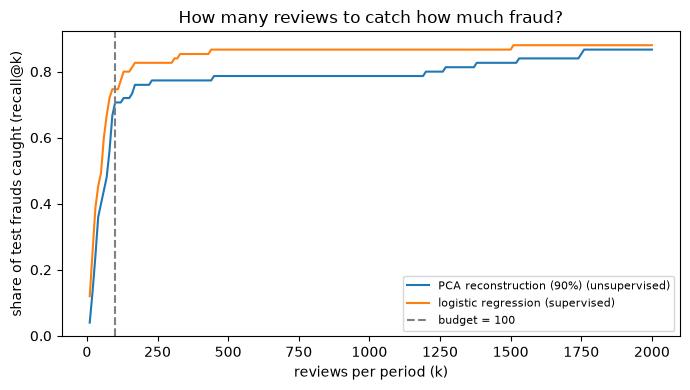

In [48]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, s in [(chosen_detector + " (unsupervised)", test_unsup), (chosen_supervised + " (supervised)", test_sup)]:
    ks = np.arange(10, 2_001, 10)
    ax.plot(ks, [recall_at_k(y_test, s, k) for k in ks], label=name)
ax.axvline(BUDGET, ls="--", c="grey", label=f"budget = {BUDGET}")
ax.set(xlabel="reviews per period (k)", ylabel="share of test frauds caught (recall@k)", title="How many reviews to catch how much fraud?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 6 — The trade-off, computed

In [49]:
u, f, s_ = final_table.iloc[0], final_table.iloc[1], final_table.iloc[2]
only_unsup = int((unsup_top & ~sup_top & (y_test == 1)).sum())
reviews_for_half_unsup = next((k for k in range(10, len(y_test), 10) if recall_at_k(y_test, test_unsup, k) >= 0.5), None)
reviews_for_half_sup = next((k for k in range(10, len(y_test), 10) if recall_at_k(y_test, test_sup, k) >= 0.5), None)
print(f"1. Unsupervised queue ({chosen_detector}): {u['frauds found']:.0f} frauds in {BUDGET} reviews (precision {u['precision']:.2f}), "
      f"recall {u['recall']:.1%}, vs {BUDGET * y_test.mean():.2f} expected from random reviews → "
      f"{u['precision'] / y_test.mean():.0f}× better than random without using a single fraud label.")
print(f"2. Fixed threshold from validation produced {f['reviews']:.0f} alerts in the test period (budget {BUDGET}) → "
      f"{'alert volume drifted: monitor it, or use a per-period top-k queue' if abs(f['reviews'] - BUDGET) > 0.2 * BUDGET else 'alert volume stayed close to the budget this time'}.")
print(f"3. Supervised queue ({chosen_supervised}): {s_['frauds found']:.0f} frauds (precision {s_['precision']:.2f}, recall {s_['recall']:.1%}, "
      f"{s_['share of fraud amount']:.0%} of fraud amount) → {s_['frauds found'] / max(u['frauds found'], 1):.1f}× the unsupervised queue's frauds for the same {BUDGET} reviews.")
print(f"4. Reviews needed to catch half the test fraud: unsupervised {reviews_for_half_unsup}, supervised {reviews_for_half_sup}.")
print(f"5. Frauds in the unsupervised top-{BUDGET} that the supervised top-{BUDGET} missed: {only_unsup} → "
      f"{'anomaly scores add some coverage: use them as a feature or reserve part of the queue for them' if only_unsup > 0 else 'no extra coverage here, but anomaly scores still matter for new fraud patterns with no labels yet'}.")

1. Unsupervised queue (PCA reconstruction (90%)): 53 frauds in 100 reviews (precision 0.53), recall 70.7%, vs 0.13 expected from random reviews → 403× better than random without using a single fraud label.
2. Fixed threshold from validation produced 77 alerts in the test period (budget 100) → alert volume drifted: monitor it, or use a per-period top-k queue.
3. Supervised queue (logistic regression): 56 frauds (precision 0.56, recall 74.7%, 64% of fraud amount) → 1.1× the unsupervised queue's frauds for the same 100 reviews.
4. Reviews needed to catch half the test fraud: unsupervised 80, supervised 60.
5. Frauds in the unsupervised top-100 that the supervised top-100 missed: 3 → anomaly scores add some coverage: use them as a feature or reserve part of the queue for them.


**Stretch goals**
1. Add the anomaly score of the chosen detector as a **feature** of the supervised model and check whether validation AP improves.
2. Split each period into smaller consecutive batches (e.g. 5 per period, 20 reviews each) and study how precision@k varies from batch to batch.
3. Make the threshold **cost-aware**: rank by `probability × Amount` (expected loss) and compare the fraud amount caught.
4. Use a **hybrid queue**: 80 reviews from the supervised model + 20 from the anomaly detector, and measure the frauds found.
5. Explain individual alerts for analysts with per-feature contributions (e.g. ECOD's per-dimension tail scores or SHAP, see [Model Interpretability](18_Model_Interpretability_SHAP_LIME.ipynb)).

### 🗣️ How to talk about this in an interview
- "I framed fraud detection as ranking under a review budget, so I chose detectors by precision@100 on a later validation period and reported recall and fraud amount caught on a held-out test period."
- "I split by time, not randomly, because fraud patterns drift and a random split would leak future behaviour into training."
- "The best unsupervised detector was far better than random reviews without using any fraud labels. I still compared it with a supervised model trained on past labels, on precision at the budget and on overall ranking quality (AP, reviews needed to catch half the fraud)."
- "A fixed threshold's alert volume can drift between periods; a per-period top-k queue guarantees the workload, and alert volume becomes a monitoring metric."
- "In production I'd run a hybrid: supervised ranking for known patterns, anomaly scores for new ones, with analyst decisions fed back as labels."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What's the difference between outlier detection, novelty detection and anomaly detection? What kinds of anomalies are there?**

<details><summary>Show answer</summary>

- **30-second answer:** Outlier detection finds strange points inside a dataset that already contains them (unsupervised). Novelty detection trains on clean normal data and flags new points that don't fit (semi-supervised). Anomaly detection is the umbrella term. Anomalies can be point (one strange record), contextual (strange given time/location/user) or collective (a strange group or sequence).
- **Go deeper:** In scikit-learn, LOF has `novelty=False` (only `fit_predict`) vs `novelty=True` (`predict` on new data). Contextual anomalies need context features or forecasting residuals; collective anomalies need window aggregates or sequence models. With enough labels that resemble future anomalies it becomes supervised imbalanced classification.
- **❌ Common wrong answer:** "Outliers are always errors that should be deleted." In fraud or safety, the outliers are the whole point.

</details>

**Q2. How does Isolation Forest work, and why does it scale?**

<details><summary>Show answer</summary>

- **30-second answer:** It builds random trees by picking a random feature and a random split between its min and max. Anomalies are few and different, so they get isolated in short paths. The score is $2^{-E[h(x)]/c(\psi)}$, near 1 for anomalies. Each tree uses a small sub-sample (256) with depth limit ⌈log₂ψ⌉, so training doesn't depend on n and scoring is linear.
- **Go deeper:** $c(n) = 2H(n-1) - 2(n-1)/n$ normalizes by the average BST search depth; sub-sampling reduces swamping and masking; `contamination` only sets the threshold (`offset_`). Weaknesses: axis-aligned splits (Extended IF uses hyperplanes), local anomalies near dense clusters, many irrelevant features. We matched its ranking from scratch (Spearman ≥ 0.95).
- **❌ Common wrong answer:** "It learns a density of the normal data" or "anomalies end up deep in the tree".

</details>

**Q3. How does Local Outlier Factor work and when would you prefer it to Isolation Forest?**

<details><summary>Show answer</summary>

- **30-second answer:** LOF compares each point's local reachability density (inverse mean reachability distance to its k neighbours) with its neighbours' densities; LOF ≫ 1 means the point is much sparser than its neighbourhood. Prefer it when clusters have very different densities and anomalies sit near dense clusters (local anomalies), on small to medium data.
- **Go deeper:** reach-dist(a, b) = max(k-distance(b), d(a, b)) smooths noise. It's O(n²) without indexes, needs scaling, is sensitive to `n_neighbors` (AP on satellite changed a lot between k=5 and k=50) and duplicates (identical rows make densities infinite). Use `novelty=True` for new data.
- **❌ Common wrong answer:** "LOF is just the distance to the k-th neighbour." That's the KNN detector; LOF is a *ratio* of densities.

</details>

**Q4. What does `nu` mean in One-Class SVM, and when would you use it?**

<details><summary>Show answer</summary>

- **30-second answer:** One-Class SVM finds a maximum-margin boundary around the training data in kernel space. `nu` is an upper bound on the fraction of training points outside the boundary and a lower bound on the fraction of support vectors. Use it for novelty detection with clean normal training data and moderate n.
- **Go deeper:** RBF `gamma` controls boundary smoothness; scaling is required; fitting is O(n²)–O(n³), so for large data use `SGDOneClassSVM` with a `Nystroem` kernel approximation (linear time; we measured it). It degrades when the training data is contaminated.
- **❌ Common wrong answer:** "`nu` is the regularization strength C."

</details>

**Q5. Why is accuracy useless for anomaly detection, and should you use ROC-AUC or PR-AUC?**

<details><summary>Show answer</summary>

- **30-second answer:** With 0.17% fraud, predicting "normal" for everything is 99.83% accurate. ROC-AUC can also look excellent (above 0.9) while most top-ranked alerts are false, because the false-positive rate divides by a huge number of normals. PR-AUC / average precision and precision@k focus on the positives and the top of the ranking, which is what analysts see.
- **Go deeper:** Random AP = prevalence, so report the baseline. Use precision@k for a review budget, recall@k for coverage, bootstrap intervals for few positives. ROC-AUC is still useful to compare rankings across datasets with different prevalence.
- **❌ Common wrong answer:** "ROC-AUC is threshold-free, so it's always the best metric."

</details>

**Q6. What does `contamination` do in scikit-learn's detectors?**

<details><summary>Show answer</summary>

- **30-second answer:** It sets the threshold (`offset_`) that turns scores into ±1 predictions, as the corresponding percentile of training scores. It doesn't change the trees, neighbours or scores: we asserted `score_samples` were identical for four contamination values.
- **Go deeper:** Rank-based metrics (AP, ROC-AUC) are unaffected by it. In practice set the threshold from a review budget or costs on validation data, and monitor alert volume. PyOD's `contamination` similarly sets `threshold_`.
- **❌ Common wrong answer:** "Contamination tells the model how many anomalies to learn, so it improves accuracy."

</details>

**Q7. Compare z-score, median/MAD, IQR and Mahalanobis approaches. When do they fail?**

<details><summary>Show answer</summary>

- **30-second answer:** z-score, robust z and IQR are univariate: fast and explainable, but blind to strange *combinations*. The z-score suffers masking because outliers inflate the mean and std; median/MAD and IQR are robust. Mahalanobis handles correlations and gives χ² thresholds, but needs a robust covariance (MCD) and assumes one elliptical cluster.
- **Go deeper:** On multimodal data (Old Faithful) one ellipse's centre falls in the empty gap, so in-between points look most normal, and MCD fits one mode and flags the other. Use mixtures, LOF or Isolation Forest there. MAD is 0 when over half the values are identical.
- **❌ Common wrong answer:** "Anything beyond 3 standard deviations is an outlier" for any distribution.

</details>

**Q8. You have 500 labelled frauds. Unsupervised or supervised?**

<details><summary>Show answer</summary>

- **30-second answer:** Supervised usually wins when labels are reliable and future fraud resembles past fraud. In our project the supervised model ranked fraud better overall (higher test AP, fewer reviews to catch half of it), while the best anomaly detector came close at exactly 100 reviews and caught a few frauds the supervised queue missed. Use both: supervised for known patterns, anomaly scores for new ones.
- **Go deeper:** Use time-based splits, PR-AUC/precision@k, class weights or threshold tuning ([Notebook 17](17_Imbalanced_Data_and_Model_Evaluation.ipynb)); add anomaly scores as features; beware label delay and selection bias (only reviewed cases get labels), so keep a random audit sample.
- **❌ Common wrong answer:** "Fraud is rare, so it must be solved with unsupervised anomaly detection."

</details>

### 💻 Coding

**Q9. Write precision@k and a budget-based threshold.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def precision_at_k(y, s, k):
      return y[np.argsort(-s)[:k]].mean()
  threshold = np.sort(val_scores)[::-1][budget - 1]   # set on validation
  alerts = new_scores >= threshold
  ```
- **Go deeper:** Use `kind="stable"` or explicit tie handling; choose the threshold on validation, never test; track alert counts over time because the score distribution drifts; a per-period top-k queue fixes the workload exactly.
- **❌ Common wrong answer:** Using `np.argsort(s)[:k]` (the k *lowest* scores) or picking the threshold on the test labels.

</details>

**Q10. Compute robust Mahalanobis distances in NumPy.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  mcd = MinCovDet(random_state=0).fit(X)
  diff = X - mcd.location_
  d = np.sqrt(np.sum(diff * np.linalg.solve(mcd.covariance_, diff.T).T, axis=1))
  ```
- **Go deeper:** `solve` avoids an explicit inverse; `mcd.mahalanobis(X)` returns **squared** distances; flag with `d² > chi2.ppf(0.975, df=d)` if roughly Gaussian. Our scratch version matched scikit-learn and SciPy exactly.
- **❌ Common wrong answer:** Using the plain sample covariance (anomalies inflate it and hide themselves: AP 0.18 vs 0.55 on annthyroid).

</details>

### 🐛 Debugging Scenarios

**Q11. Your KNN/LOF detector flags almost only very large transactions, and fraud analysts say the alerts are useless. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Probably unscaled features: `Amount` in the thousands dominates Euclidean distance (it held almost all the variance in Pitfall 4). Scale features (robust scaling for heavy tails), reconsider which features matter, and evaluate with precision@k on reviewed cases.
- **Go deeper:** Large amounts can be a *contextual* anomaly (normal for some customers): add per-customer context such as amount relative to the customer's history. Check score contributions per feature to see what drives alerts.
- **❌ Common wrong answer:** "Lower the contamination so fewer large transactions are flagged."

</details>

**Q12. Alert volume doubled overnight but nobody changed the model. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Input drift or a data pipeline change: a fixed score threshold turns any shift in the score distribution into more alerts. Check feature distributions and missing/default values, upstream schema or unit changes, and whether a real event (a fraud attack, a holiday) happened.
- **Go deeper:** Monitor alert counts and score quantiles, compare against a reference window, use a per-period top-k queue or a quantile-based threshold for workload stability, and retrain/recalibrate on recent normal data when the shift is legitimate. We saw a validation-set threshold give a different alert count on a later period.
- **❌ Common wrong answer:** "Increase contamination until the volume goes back down" without finding the cause.

</details>

**Q13. LOF gives you warnings about duplicates and some scores are astronomically large. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Many identical rows (more than `n_neighbors`) make k-distances zero and local densities infinite, so LOF ratios blow up. Deduplicate (score distinct rows and map back), increase `n_neighbors` beyond the largest duplicate group if feasible, or add tiny noise, then re-evaluate.
- **Go deeper:** In mammography one row appeared thousands of times. Also check why duplicates exist (default values, rounding, data joins). Remember that deduplication discards frequency information, and frequent rows are normal.
- **❌ Common wrong answer:** "Ignore the warning; the ranking is still fine."

</details>

### 🏗️ Design

**Q14. Design a card-fraud detection system with a human review team of 20 analysts.**

<details><summary>Show answer</summary>

- **30-second answer:** Real-time scoring at authorization with a fast supervised model (gradient boosting on engineered features: amount vs customer history, velocity counts, merchant and device risk) plus anomaly scores for unseen patterns; rules for hard blocks; a ranked review queue sized to analyst capacity; analyst decisions and chargebacks flow back as labels for retraining.
- **Go deeper:** Time-based validation, precision@capacity and fraud amount caught as KPIs; expected-loss ranking (probability × amount); latency budget (tens of ms) with a feature store for streaming aggregates; drift and alert-volume monitoring; handling label delay and selection bias with a random audit sample; explanations for analysts; A/B or shadow deployment before switching models.
- **❌ Common wrong answer:** "Train an Isolation Forest on all transactions and block everything above contamination = 1%."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** Two `IsolationForest` models with the same `random_state` and data, one with `contamination=0.01` and one with `contamination=0.2`. Are their `score_samples` outputs identical?
<details><summary>Answer</summary>

**Yes.** Contamination only changes `offset_`, the threshold used by `predict`.
</details>

**2.** In scikit-learn's `IsolationForest`, do anomalies get **higher** or **lower** `score_samples` values than normal points? And in PyOD's `IForest.decision_scores_`?
<details><summary>Answer</summary>

**Lower** in scikit-learn (`score_samples` = −s, higher = more normal); **higher** in PyOD (higher = more anomalous). Always check the sign convention before computing AP.
</details>

**3.** What happens with `LocalOutlierFactor().fit(X_train).predict(X_new)`?
<details><summary>Answer</summary>

`AttributeError`: `predict` is only available with `novelty=True`. With the default `novelty=False`, use `fit_predict` on the data itself.
</details>

**4.** You score 100,000 cases, 1% of them anomalies, with **random** numbers. Roughly what average precision do you get?
<details><summary>Answer</summary>

About **0.01**: a random ranking's AP is close to the anomaly rate. (Its ROC-AUC would be about 0.5.)
</details>

**5.** With `IsolationForest(max_samples=256)`, what is the maximum depth of each tree?
<details><summary>Answer</summary>

**8** = ⌈log₂ 256⌉. Deeper splits wouldn't help: anomalies are isolated long before that.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Novelty and Outlier Detection](https://scikit-learn.org/stable/modules/outlier_detection.html) — outlier vs novelty mode, Isolation Forest, LOF, One-Class SVM, EllipticEnvelope
- [scikit-learn — IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) — parameters, `score_samples`, `offset_`
- [scikit-learn — Comparing anomaly detection algorithms for outlier detection on toy datasets](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_anomaly_comparison.html) — decision boundaries of each method side by side
- [PyOD documentation](https://pyod.readthedocs.io/en/latest/) — the unified API and 50+ detectors used in Section 7

### 🎥 Videos
- [PyData Amsterdam 2019 — Jan van der Vegt: A walk through the isolation forest](https://www.youtube.com/watch?v=RyFQXQf4w4w) (~24 min) — builds the intuition, path lengths and the score step by step; pairs with Section 4 and the from-scratch build
- [PyData London — Elena Sharova: Unsupervised Anomaly Detection with Isolation Forest](https://www.youtube.com/watch?v=5p8B2Ikcw-k) (~33 min) — applying Isolation Forest in practice and defining what counts as an anomaly
- [PyData Prague #25 — Lucie Blechová: Demystifying Anomaly Detection](https://www.youtube.com/watch?v=8Fp1_C5i5lc) (~37 min) — an overview of anomaly types, methods and evaluation in industry; pairs with Sections 1 and 8

### 📄 Papers
- [Liu, Ting & Zhou (2008) — Isolation Forest (IEEE ICDM)](https://doi.org/10.1109/ICDM.2008.17) — the original algorithm and the $c(n)$ normalization
- [Breunig, Kriegel, Ng & Sander (2000) — LOF: Identifying Density-Based Local Outliers (ACM SIGMOD)](https://doi.org/10.1145/342009.335388) — reachability distance and local density
- [Zhao, Nasrullah & Li (2019) — PyOD: A Python Toolbox for Scalable Outlier Detection](https://www.jmlr.org/papers/v20/19-011.html) — the PyOD paper (JMLR)
- [Han et al. (2022) — ADBench: Anomaly Detection Benchmark](https://arxiv.org/abs/2206.09426) — 30 algorithms on 57 datasets: no unsupervised method wins everywhere

### 📘 Books & Courses
- [Machine Learning Specialization — DeepLearning.AI (Andrew Ng)](https://www.deeplearning.ai/courses/machine-learning-specialization/) — Course 3 teaches Gaussian anomaly detection and when to prefer supervised learning
- [ADBench on GitHub](https://github.com/Minqi824/ADBench) — code and datasets to benchmark detectors yourself

### 🏋️ Practice
- [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — the mini project's dataset, with many public notebooks to compare against
- [Kaggle — IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection) — a larger, messier real fraud competition with rich features

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Outlier vs novelty | score contaminated data vs new data after clean training | `fit_predict` vs `LocalOutlierFactor(novelty=True).predict` |
| Robust z / IQR | univariate, masking-resistant flags | $0.6745(x-\tilde x)/\text{MAD}$; $[Q_1 - 1.5\,\text{IQR}, Q_3 + 1.5\,\text{IQR}]$ |
| Mahalanobis | correlation-aware distance, χ² threshold | `MinCovDet().mahalanobis(X)` (squared), `EllipticEnvelope` |
| Isolation Forest | short random isolation paths = anomalous | $s = 2^{-E[h]/c(\psi)}$, `IsolationForest(max_samples=256)` |
| LOF | density relative to neighbours | `LocalOutlierFactor(n_neighbors=20)`, `-negative_outlier_factor_` |
| One-Class SVM | boundary around normal data | `OneClassSVM(nu=0.05)`; big n: `Nystroem` + `SGDOneClassSVM` |
| Density / reconstruction | low likelihood or large residual | `-GaussianMixture().score_samples`, PCA $\lVert x - \hat x\rVert^2$ |
| PyOD | one API, many detectors | `fit`, `decision_scores_`, `decision_function`, `threshold_`; ECOD, COPOD, HBOS, KNN |
| Combining | standardize, then average/max | `pyod.utils.utility.standardizer` |
| Metrics | ranking quality under rarity | `average_precision_score`, precision@k, recall@k; not accuracy |
| contamination | threshold only | changes `offset_`/`predict`, never `score_samples` |
| Budget threshold | k-th highest validation score | `np.sort(val_scores)[::-1][k - 1]`; monitor alert volume |
| Protocol | fair comparison | same folds, labels only for grading, time-based splits for fraud |

## ➡️ What's Next

**[16 · Feature Engineering and Selection](16_Feature_Engineering_and_Selection.ipynb)** — anomaly detectors and supervised models are only as good as their inputs; next you'll build features such as ratios, aggregates and encodings (including anomaly scores themselves) and learn to select the ones that actually help.